# Confirmation Bias Project
## LMM analyses: Behavioural analyses
Launching analysis for each of the experiments: ['3reps', 'CJ']

__Here we modelled the data with GLMM and then plot the parameters__

We recommend to run this script in Jupyter Notebook. It is possible to not visualize some plots in JupyterLab

__Metadprime was computed using the library from:__

pip install git+https://github.com/LegrandNico/metadPy.git

##### Import important functions and libraries

In [1]:
import os, glob, platform, sys
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy
import scipy.stats as stats
from scipy import signal
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM


from statsmodels.stats.multicomp import (pairwise_tukeyhsd, MultiComparison)
from matplotlib.lines import Line2D
import statsmodels as sms
#import ptitprince as pt
#pd.options.display.max_columns = None # display all the columns in pandas dataframe
#import plotly.graph_objects as go
#import plotly.express as px
#from plotly.subplots import make_subplots
# import psychofit as psy
from pymer4.models import Lmer
import time

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../Helper_funcs')))
from use_funcs import *

#import metadpy



In [2]:
import io
import base64
from IPython.display import display, HTML

def generate_report(model, round_digits=3, title="Table 1: Mixed-Effects Model Summary", save_path=None, include_plot=False):
    if not hasattr(model, 'coefs') or model.coefs is None:
        raise ValueError("Model has no coefficients. Did you run .fit()?")
        
    df = model.coefs.copy()
    img_html = "" 
    
    # --- 1. OPTIONAL: GENERATE THE FOREST PLOT ---
    if include_plot:
        plt.figure(figsize=(8, len(df) * 0.5 + 1))
        predictors = [str(x).replace(':', ' × ') for x in df.index]
        estimates = df['Estimate'].values
        
        if '2.5_ci' in df.columns and '97.5_ci' in df.columns:
            err_lower = estimates - df['2.5_ci'].values
            err_upper = df['97.5_ci'].values - estimates
            errors = [err_lower, err_upper]
        else:
            errors = df['SE'].values * 1.96

        plt.errorbar(estimates, range(len(predictors)), xerr=errors, fmt='o', color='#2c3e50', 
                     capsize=5, capthick=2, elinewidth=2, markersize=8)
        plt.yticks(range(len(predictors)), predictors)
        plt.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2)
        plt.xlabel('Effect Size (Beta / Log-Odds)')
        plt.title('Fixed Effects Coefficients (with 95% CIs)')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.gca().invert_yaxis()
        
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
        plt.close()
        buf.seek(0)
        plot_base64 = base64.b64encode(buf.read()).decode('utf-8')
        img_html = f'<div style="text-align: center; margin-bottom: 20px;"><img src="data:image/png;base64,{plot_base64}" style="max-width: 100%; border: 1px solid #ddd; border-radius: 5px; padding: 10px; background: white;"></div>'

    # --- 2. FORMAT THE HTML TABLE ---
    stat_name = 'Z-stat' if 'Z-stat' in df.columns else 'T-stat'
    stat_label = 'z' if stat_name == 'Z-stat' else 't'
    
    table = df[['Estimate', 'SE', stat_name, 'P-val']].copy()
    table = table.reset_index()
    table.columns = ['Predictor', 'Beta', 'SE', stat_label, 'p-value']
    
    def get_stars(p):
        if pd.isna(p): return ''
        elif p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        elif p < 0.1: return '†'
        return ''
    
    table['Sig'] = table['p-value'].apply(get_stars)
    table['Beta'] = table['Beta'].apply(lambda x: f"{x:.{round_digits}f}")
    table['SE'] = table['SE'].apply(lambda x: f"{x:.{round_digits}f}")
    table[stat_label] = table[stat_label].apply(lambda x: f"{x:.{round_digits}f}")
    table['p-value'] = table['p-value'].apply(lambda x: '< .001' if x < 0.001 else f"{x:.{round_digits}f}")
    table['Predictor'] = table['Predictor'].apply(lambda x: str(x).replace(':', ' × '))
    
    styles = [
        # Override Jupyter's left-align override
        {'selector': 'table', 'props': [('margin-left', 'auto'), ('margin-right', 'auto')]},
        {'selector': 'thead th', 'props': [('border-top', '2px solid black'), ('border-bottom', '1px solid black'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'tbody td', 'props': [('text-align', 'center'), ('padding', '6px 10px'), ('border-bottom', 'none')]},
        {'selector': 'tbody td:first-child', 'props': [('text-align', 'left')]},
        {'selector': 'tbody tr:last-child td', 'props': [('border-bottom', '2px solid black')]},
    ]
    
    table_html = table.style.hide(axis="index").set_table_styles(styles).to_html()

    # --- 3. BUILD THE FINAL HTML PAGE ---
    formula = model.formula
    n_obs = getattr(model, 'data', pd.DataFrame()).shape[0] if hasattr(model, 'data') else "Unknown"

    final_html = f"""
    <div style="font-family: Arial, sans-serif; max-width: 900px; margin: 20px auto; background: #fafafa; padding: 20px; border-radius: 8px;">
        <h3 style="margin-bottom: 8px; color: #222; text-align: center;">{title}</h3>
        <div style="margin-bottom: 20px; font-size: 14px; color: #444; line-height: 1.5; text-align: center;">
            <b>Formula:</b> <code>{formula}</code><br>
            <b>Observations:</b> {n_obs}
        </div>
        
        {img_html}
        
        <div style="background: white; padding: 15px; border-radius: 5px; box-shadow: 0 1px 3px rgba(0,0,0,0.1);">
            <div style="display: flex; justify-content: center; width: 100%;">
                {table_html}
            </div>
            
            <div style="margin-top: 10px; font-size: 13px; color: #555; text-align: center;">
                <em>Note: *** p &lt; 0.001, ** p &lt; 0.01, * p &lt; 0.05, † p &lt; 0.1</em>
            </div>
        </div>
    </div>
    """
    
    if save_path:
        with open(save_path, "w", encoding="utf-8") as file:
            file.write(final_html)
            
    return HTML(final_html)

In [3]:
colpal1 = ["orange","green"]
colpal1a = ["deeppink","deepskyblue"]
#colpal2 = ['black','green','blue']

colpal1b = ['dodgerblue','navy']
colpal3 = ['springgreen','darkviolet']
colpal2 = ['gold','mediumturquoise','darkblue']


In [4]:
# Importing behavioral data from experiment 
if platform.system() == 'Darwin':
    sys_dir = os.path.join('/Users','alex','Library','CloudStorage','OneDrive-UniversitatdeBarcelona') # macv
    results_path = '/Users/alex/OneDrive - Universitat de Barcelona/Projects/Condcision/'
  
if platform.system() == 'Linux':
    sys_dir = os.path.join('/home','freeman','Insync', 'alexisperez@ub.edu', 'OneDrive Biz')  # Linux   
    results_path = '/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/' # Linux Mundet
    #results_path = '/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/Projects/Condcision/' # Home Mundet


figures_path = os.path.join(results_path, 'Group_level_analyses','figures') 
# some folders with interesting custom functions
path_utils = os.path.join(sys_dir, 'TOOLBOXES','decoding_toolbox_py','Helper_funcs') 
psychofits = os.path.join(sys_dir, 'TOOLBOXES','psychofit-master')  
sys.path.append(path_utils)
sys.path.append(psychofits)

__Dataset created in Group_Behav_Analyses__

In [5]:
df = pd.read_csv('./all_data_CSV/cond_df.csv')

__Loading metadprime values for CJ experiment in each nrep and merge with the dataset__

In [6]:
metad_dfile = os.path.join('/home/freeman/Insync/alexisperez@ub.edu/OneDrive Biz/PROJECTS/Condcision/Behav_data/Behavioral/condcisionCJ', 'metad_df')
metad_dfile = os.path.join('/Users/alex/Library/CloudStorage/OneDrive-UniversitatdeBarcelona/Projects/Condcision/Behav_data/Behavioral/condcisionCJ', 'metad_df')
meta_dprimes = pd.read_pickle(metad_dfile)
meta_dprimes['exp_ID'] = 'CJ'


meta_dprimes = meta_dprimes.rename(columns={
    'mean': 'nrep_metad',
    'metac_eff': 'nrep_metad_eff'
})



# Preparing the data in long format

In [7]:
# df to long format
dflong = pd.melt(df, id_vars=['exp_ID','id_subj','rDV','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','rtconf1','ITI','trial_type','rt','metad','metad_MLE', 'm_ratio', 'metad_eff'], value_vars=['d1', 'd2', 'd3', 'd4', 'd5', 'd6'])
dflong.shape
dflong.rename(columns={'variable' : "stim", 'value' : 'dv'}, inplace=True)

out = pd.melt(df, id_vars=['exp_ID','id_subj','rDV','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','rtconf1','ITI','trial_type','rt','metad','metad_MLE', 'm_ratio', 'metad_eff'], value_vars=['o1', 'o2', 'o3', 'o4', 'o5', 'o6'])
dflong['orient'] = out.value
dflong.orient = np.rad2deg(dflong.orient) # transform to degrees
del out

dflong = dflong.sort_values(['nblock','id_subj','ntrial','nrep',],ascending=[True,True,True,True]) # reorder variables
dflong.reset_index(drop=True, inplace=True)
dflong.insert(5, "stim_cond", "D")
dflong.loc[(dflong.dv < 0), "stim_cond"]  = "C"


dflong.insert(7, 'cong_deci', "I") # if stim is congruent with previous repetition decosion category
# an stimuli is expected when the previous dv and previous deci were the same (i.e.DV==D & pre_deci == D)
dflong.loc[(dflong['response1'] == 0) & (dflong.stim_cond == 'C') | (dflong['response1'] == 1) & (dflong.stim_cond == 'D'), "cong_deci"]  = "C"



dflong.insert(8, 'cong_stim', 'I') # if stim is congruent with previous repetition mean category
dflong.loc[(dflong['response1'] == 0) & (dflong.stim_cond == 'C') | (dflong['response1'] == 'D') & (dflong.stim_cond == 'D'), 'cong_stim'] = 'C'

# relabeling variables
#dflong["cond-1"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci-1"].replace({0: "C", 1: "D"}, inplace=True)
#dflong["deci-2"].replace({0: "C", 1: "D"}, inplace=True)


dflong['ov'] = signal.sawtooth(2*np.deg2rad(dflong.orient), 0.5) # orientation variable (here I define an ov to make stimuli that differ by less of 45 degrees or more than 135 as similar)
# plt.scatter(dflong.orient,dflong['ov']) # see here
dflong['nrepp'] = dflong['nrep'].astype(int)
dflong.loc[dflong['nrepp'] > 0, 'nrepp'] = 1

dflong.head(5)

,exp_ID,id_subj,rDV,nrep,rep,stim_cond,nblock,cong_deci,cong_stim,ntrial,...,rt,metad,metad_MLE,m_ratio,metad_eff,stim,dv,orient,ov,nrepp
0,3diffs,1,0.185048,0,diff,C,0,C,C,0,...,1.646,NaN,NaN,NaN,NaN,d1,-0.022671,68.010090,0.511335,0
1,3diffs,1,0.185048,0,diff,D,0,I,I,0,...,1.646,NaN,NaN,NaN,NaN,d2,0.566085,35.236904,-0.216958,0
2,3diffs,1,0.185048,0,diff,C,0,C,C,0,...,1.646,NaN,NaN,NaN,NaN,d3,-0.622602,98.491445,0.811301,0
3,3diffs,1,0.185048,0,diff,D,0,I,I,0,...,1.646,NaN,NaN,NaN,NaN,d4,0.398017,31.455383,-0.300991,0
4,3diffs,1,0.185048,0,diff,D,0,I,I,0,...,1.646,NaN,NaN,NaN,NaN,d5,0.095505,114.648855,0.452248,0


Sorting stimuli as a function to the difference with previous angle in the sequence

In [8]:
# calculating angular difference between contiguous angles
diff1 = circ_angles_diff(df.o2,df.o1)
diff2 = circ_angles_diff(df.o3,df.o2)
diff3 = circ_angles_diff(df.o4,df.o3)
diff4 = circ_angles_diff(df.o5,df.o4)
diff5 = circ_angles_diff(df.o6,df.o5)

# getting absolute difference and getting indexes sorting by distance (first the more similar to previous stim, and last the more different to previous stim).
prev_respdiff = np.abs(pd.concat([diff1,diff2,diff3,diff4,diff5], axis = 1))
prev_respdiff = prev_respdiff.to_numpy()
sort_idx = prev_respdiff.argsort(axis = 1)

#orientations = np.matrix(df.iloc[:, 24:30])
orientations = np.matrix(df[['d2','d3','d4','d5','d6']]) 
orientations = np.take_along_axis(orientations,sort_idx, axis = 1)
reo_orientations = pd.DataFrame(orientations,columns=['G1Asim','G2Asim','G3Asim','G4Asim','G5Asim'])
df_glm = pd.concat([df, reo_orientations],axis = 1)

Sorting stimuli based on their DV difference with respect to the previous stimulus

In [9]:
diff1 = df.d2 - df.d1
diff2 = df.d3 - df.d2
diff3 = df.d4 - df.d3
diff4 = df.d5 - df.d4
diff5 = df.d6 - df.d5

prev_respdiff = np.abs(pd.concat([diff1,diff2,diff3,diff4,diff5], axis = 1))
prev_respdiff = prev_respdiff.to_numpy()
#plt.hist(prev_respdiff)

sort_idx = prev_respdiff.argsort(axis = 1)

orientations = np.matrix(df[['d2','d3','d4','d5','d6']]) 
orientations = np.take_along_axis(orientations,sort_idx, axis = 1)

reo_orientations = pd.DataFrame(orientations,columns=['G1DVsim','G2DVsim','G3DVsim','G4DVsim','G5DVsim'])
df_glm = pd.concat([df_glm, reo_orientations],axis = 1)

__Make it long__

In [10]:
dflong_glm = pd.melt(df_glm, id_vars=['exp_ID','id_subj','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','ITI','trial_type','rt','metad','metad_MLE', 'm_ratio', 'metad_eff'], value_vars=['G1Asim','G2Asim','G3Asim','G4Asim','G5Asim'])
dflong_glm.rename(columns = {'value':'angle_diff'}, inplace = True)
out = pd.melt(df_glm, id_vars=['exp_ID','id_subj','nrep','rep','nblock','ntrial','stimuli1','Stimuli', 'response2','response1','Responses', 'accuracy1', 'Confidence1','ITI','trial_type','rt','metad','metad_MLE', 'm_ratio', 'metad_eff'], value_vars=['G1DVsim','G2DVsim','G3DVsim','G4DVsim','G5DVsim'])
dflong_glm['dv_diff'] = out.value

__Accuracy, dprime and criterion calculation (for all the experiments)__

In [11]:
# function that I used to plot multiple data
def barsplot(data, dx, dy, hue, col, row, pal, size, yaxis, axislabels, sizepoint, dodge):    
    sns.set(font_scale = 1.5, style = 'ticks')         
    ort = "v"; pal = pal; sigma = .5
    g = sns.FacetGrid(data ,  row = row, col = col, height= size['height'], aspect=size['aspect'], margin_titles=True) # col="nrep",    
    if sizepoint == None:
        sizepoint = 6
    if yaxis != None:
        g.set(yaxis['ylim'], yaxis['yticks'])   

    g.map_dataframe(sns.stripplot, x = dx, y = dy, palette = pal, hue=hue, size = sizepoint, edgecolor = "white",
                    linewidth = 0.6, jitter = 0.2, orient = ort,alpha = 0.5, dodge=dodge)
    g.map_dataframe(sns.barplot, x = dx, y = dy, palette = pal, hue=hue,  linewidth = 0.6, orient = ort, dodge=dodge)
    
    #g.map_dataframe(sns.violinplot, x = dx, y = dy,  palette = pal,bw = .5, cut = 0.,scale = "area", width = .6, inner = None, orient = ort, linewidth = 0, zorder = 2)
    
    g.add_legend()

    sns.despine(offset = .5,  trim=True);
    # Set x-axis and y-axis labels
    g.set_axis_labels( axislabels['xlabel'] , axislabels['ylabel'], fontsize = 15 )
    #g.tight_layout()
    return g


## General Linear mixed effects models

__Loading and saving LM models in a dictionary file__

__write__

with open('./all_data_CSV/LLMs_models', 'wb') as fp:
    pickle.dump(lmm_models, fp)
    print('dictionary saved successfully to file')

In [12]:
with open("./all_data_CSV/LLMs_models", "rb") as f:
    lmm_models = pickle.load(f)

with open("./all_data_CSV/LLMs_models", "rb") as f:
    lmm_models = pickle.load(f)


# dict to save the models
lmm_models = {}
lmm_models['all_exp'] = {}
lmm_models['reps_exp'] = {}
lmm_models['diffs_exp'] = {}
lmm_models['CJ_exp']= {}
lmm_models['reps_lag'] = {}



__Preparing data for plotting__

## 3 reps experiments

__3 exact repetitions__

In [14]:
md_3reps_exp = Lmer("Responses ~ rDV  * response1 * nrep + (rDV|id_subj)", data=df[(df.exp_ID == '3reps')], family="binomial")
md_3reps_exp.fit(factors = {"nrep": ['0','1','2']})
lmm_models['reps_exp']['md_3reps_exp'] = md_3reps_exp


/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "SideResp1". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*nrep+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 19440	 Groups: {'id_subj': 27.0}

Log-likelihood: -8483.514 	 AIC: 16997.027

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.068  0.262
id_subj          rDV  1.259  1.122

                 IV1  IV2   Corr
id_subj  (Intercept)  rDV  0.079

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


__Within stimuli effects__

In [15]:
dat = dflong[(dflong.exp_ID == '3reps')]
md_stim_exp = Lmer("Responses ~ dv : stim + ( dv|id_subj)", data= dat, family="binomial")
md_stim_exp.fit()
lmm_models['reps_exp']['md_stim_exp'] = md_stim_exp


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~dv:stim+(dv|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 116640	 Groups: {'id_subj': 27.0}

Log-likelihood: -72666.246 	 AIC: 145352.492

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.097  0.312
id_subj           dv  0.025  0.158

                 IV1 IV2   Corr
id_subj  (Intercept)  dv  0.309

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


In [34]:
dat = dflong_glm[(dflong_glm.exp_ID == '3reps')]
md_anglediff_stim_exp = Lmer("Responses ~ angle_diff : variable + ( 1|id_subj)", data= dat, family="binomial")
md_anglediff_stim_exp.fit()
lmm_models['reps_exp']['md_anglediff_stim_exp'] = md_anglediff_stim_exp


/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "id_subj". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "nrep". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "ITI". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  w

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~angle_diff:variable+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 97200	 Groups: {'id_subj': 27.0}

Log-likelihood: -60445.169 	 AIC: 120904.338

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.095  0.308

No random effect correlations specified

Fixed effects:



In [33]:
dat = dflong_glm[(dflong_glm.exp_ID == '3reps')]
md_dvdiff_stim_exp = Lmer("Responses ~ dv_diff : variable + ( 1|id_subj)", data= dat, family="binomial")
md_dvdiff_stim_exp.fit()
lmm_models['reps_exp']['md_dvdiff_stim_exp'] = md_dvdiff_stim_exp 


/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "id_subj". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "nrep". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "ITI". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  w

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~dv_diff:variable+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 97200	 Groups: {'id_subj': 27.0}

Log-likelihood: -59888.431 	 AIC: 119790.861

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.097  0.311

No random effect correlations specified

Fixed effects:



In [32]:
lmm_models['reps_exp']['md_dvdiff_stim_exp'].summary()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~dv_diff:variable+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 97200	 Groups: {'id_subj': 27.0}

Log-likelihood: -59888.431 	 AIC: 119790.861

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.097  0.311

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.507,0.389,0.625,0.060,1.661,1.476,1.869,0.624,0.596,0.651,8.415,0.0,***
dv_diff:variableG1Asim,1.426,1.371,1.481,0.028,4.161,3.938,4.397,0.806,0.798,0.815,50.753,0.0,***
dv_diff:variableG2Asim,1.392,1.336,1.449,0.029,4.024,3.802,4.259,0.801,0.792,0.810,48.081,0.0,***
dv_diff:variableG3Asim,1.137,1.081,1.194,0.029,3.118,2.947,3.299,0.757,0.747,0.767,39.507,0.0,***
dv_diff:variableG4Asim,0.690,0.638,0.741,0.026,1.993,1.893,2.098,0.666,0.654,0.677,26.224,0.0,***
dv_diff:variableG5Asim,0.378,0.334,0.422,0.023,1.459,1.396,1.526,0.593,0.583,0.604,16.684,0.0,***


In [26]:

dat = df[(df.exp_ID == '3reps')]

md_3reps_full_confi_exp = Lmer("Responses ~  rDV  * response1 * rtconf1 * nrep + (1|id_subj)", data= dat, family="binomial")
md_3reps_full_confi_exp.fit(factors = {"nrep": ['0','1','2']})
#lmm_models['CJ_exp']['md_CJ_full_confi_exp'] = md_CJ_full_confi_exp

/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "SideResp1". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*rtconf1*nrep+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 19440	 Groups: {'id_subj': 27.0}

Log-likelihood: -8566.580 	 AIC: 17183.160

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.079  0.281

No random effect correlations specified

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.472,0.331,0.613,0.072,1.603,1.392,1.846,0.616,0.582,0.649,6.558,0.000,***
rDV,2.899,2.612,3.187,0.146,18.163,13.631,24.204,0.948,0.932,0.960,19.794,0.000,***
response1,0.206,0.085,0.326,0.061,1.229,1.089,1.386,0.551,0.521,0.581,3.349,0.001,***
rtconf1,-0.046,-0.146,0.053,0.051,0.955,0.864,1.054,0.488,0.464,0.513,-0.914,0.361,
nrep1,-1.572,-1.717,-1.426,0.074,0.208,0.180,0.240,0.172,0.152,0.194,-21.181,0.000,***
nrep2,-1.752,-1.898,-1.607,0.074,0.173,0.150,0.201,0.148,0.130,0.167,-23.566,0.000,***
rDV:response1,0.268,-0.108,0.645,0.192,1.308,0.897,1.905,0.567,0.473,0.656,1.396,0.163,
rDV:rtconf1,-0.099,-0.382,0.185,0.145,0.906,0.682,1.203,0.475,0.406,0.546,-0.683,0.495,
response1:rtconf1,-0.011,-0.139,0.118,0.066,0.989,0.870,1.125,0.497,0.465,0.529,-0.162,0.872,
rDV:nrep1,-0.885,-1.329,-0.442,0.226,0.413,0.265,0.643,0.292,0.209,0.391,-3.916,0.000,***


In [78]:
report_no_plot = generate_report(
    md_3reps_full_confi_exp, 
    title="Table 1: Mixed-Effects Logistic Regression: RTconf-1",
    save_path="md_3reps_full_confi_exp.html",
    include_plot=False  # <-- The plot is turned off!
)

display(report_no_plot)

Predictor,Beta,SE,z,p-value,Sig
(Intercept),0.472,0.072,6.558,< .001,***
rDV,2.899,0.146,19.794,< .001,***
response1,0.206,0.061,3.349,< .001,***
rtconf1,-0.046,0.051,-0.914,0.361,
nrep1,-1.572,0.074,-21.181,< .001,***
nrep2,-1.752,0.074,-23.566,< .001,***
rDV × response1,0.268,0.192,1.396,0.163,
rDV × rtconf1,-0.099,0.145,-0.683,0.495,
response1 × rtconf1,-0.011,0.066,-0.162,0.872,
rDV × nrep1,-0.885,0.226,-3.916,< .001,***


Organizing coefficients for plotting

In [69]:
md_stim_coefs = lmm_models['reps_exp']['md_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_stim_coefs.reset_index(inplace = True)
md_stim_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)

md_dvdiff_coefs = lmm_models['reps_exp']['md_dvdiff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_dvdiff_coefs.reset_index(inplace = True)
md_dvdiff_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)

md_anglediff_coefs = lmm_models['reps_exp']['md_anglediff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_anglediff_coefs.reset_index(inplace = True)
md_anglediff_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)

stim_models = [md_dvdiff_coefs, md_anglediff_coefs]

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/49350533.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_stim_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/49350533.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_dvdiff_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/49350533.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.py

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3015095721.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3015095721.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3015095721.py:10: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfv

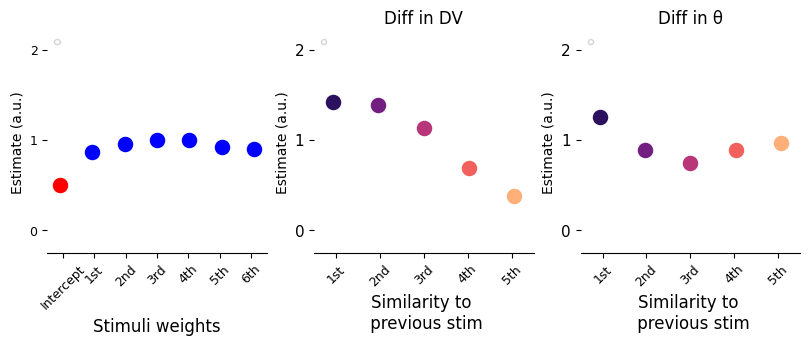

In [70]:

#estims = md_3reps_betas.copy()
fig, axes = plt.subplots(1, 3, figsize=(8,2.5))
fig.tight_layout(pad=0.0)


# First I plot the betas of each stim and intercept
i = 0
#axes[i].set_title(iparam, fontsize=15)
stim = md_stim_coefs
g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
dodge=True, join=False, ci=None,scale=1.5,  palette = ['red','blue','blue','blue','blue','blue','blue'], errwidth=0, capsize=0, ax=axes[i])
plt.setp(g.collections, alpha=.6) # set alpha for all points
# Find the x,y coordinates for each point



axes[i].spines['top'].set_visible(False)
axes[i].spines['right'].set_visible(False)
axes[i].spines['left'].set_visible(False)
# for legend text
axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
axes[i].set_xlabel('Parameter', fontsize = 0)
axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

axes[i].set_xlabel('Stimuli weights', fontsize = 12)
axes[i].margins(y=0.2)
axes[i].set_ylim([-.25, 2.2])
axes[i].set_yticks([0,1,2])
axes[i].set_xticklabels(['Intercept', '1st','2nd','3rd','4th','5th','6th'], rotation=45)
axes[i].tick_params(axis='y', labelsize=9) 
axes[i].tick_params(axis='x', labelsize=9) 

# Second, I plot the betas as a function of the physical and dv difference
sp_titles = ['Diff in DV','Diff in θ']

for i, iparam in enumerate(stim_models):
    i = i+1
    axes[i].set_title(sp_titles[i-1], fontsize=12)
    stim = iparam[iparam['parameter']  != '(Intercept)']
    g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5,  palette = "magma", errwidth=0, capsize=0, ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    #axes[i].spines['bottom'].set_visible(False)

    # for legend text
    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
    
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].set_xlabel('Similarity to \n previous stim', fontsize = 12)
    axes[i].margins(y=0.2)
    axes[i].set_ylim([-.25, 2.2])
    axes[i].set_yticks([0,1,2])
    axes[i].set_xticklabels(['1st','2nd','3rd','4th','5th'], rotation=45)
    axes[i].tick_params(axis='x', labelsize=9) 
    axes[i].tick_params(axis='y', labelsize=11) 


figpath = os.path.join(figures_path, '3reps_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)

__Effect of previous choice__

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3603900450.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3603900450.py:14: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3603900450.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfv

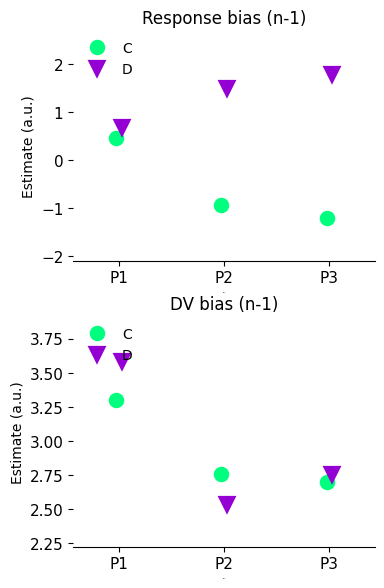

In [110]:
x_limits = np.array([[-2.5, 2.5] ,[-0.5, 1.5]])
estims = organize_data_betas(lmm_models['reps_exp']['md_3reps_exp'].coefs, 2, False)


fig, axes = plt.subplots(2, 1, figsize=(4,6))
fig.tight_layout(pad=2)

sp_titles = ['Response bias (n-1)','DV bias (n-1)']

for i, iparam in enumerate(['bias','weight']):

    axes[i].set_title(sp_titles[i], fontsize=12)
    stim = estims[estims.parameter == iparam]
    g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)

    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

    axes[i].margins(y=0.3)
    
    axes[i].set_xlabel('nrep', fontsize = 0)
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].margins(x=0.2)
    axes[i].set_xticks([0,1,2])
    axes[i].set_xticklabels(['P1', 'P2', 'P3'])
    axes[i].tick_params(axis='y', labelsize=11) 
    axes[i].tick_params(axis='x', labelsize=11) 



figpath = os.path.join(figures_path, '3reps_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


# CJ experiment

In [15]:
md_CJ_rep_exp = Lmer("Responses ~ rDV  * response1 * trial_type * nrep + (1|id_subj)", data=df[(df.exp_ID == 'CJ')], family="binomial")
md_CJ_rep_exp.fit(factors = {"nrep": ['0','1']})
lmm_models['CJ_exp']['md_CJ_rep_exp'] = md_CJ_rep_exp


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*trial_type*nrep+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13024	 Groups: {'id_subj': 37.0}

Log-likelihood: -6356.273 	 AIC: 12746.546

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.121  0.348

No random effect correlations specified

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


In [18]:
report_no_plot = generate_report(
    md_CJ_rep_exp, 
    title="Table 2: Mixed-Effects Repetition effect",
    save_path="md_CJ_rep_exp.html",
    include_plot=False  # <-- The plot is turned off!
)

display(report_no_plot)

Predictor,Beta,SE,z,p-value,Sig
(Intercept),0.505,0.087,5.796,< .001,***
rDV,4.102,0.259,15.819,< .001,***
response1,0.106,0.086,1.231,0.218,
trial_typerepeat,-0.061,0.093,-0.654,0.513,
nrep1,-0.937,0.098,-9.608,< .001,***
rDV × response1,0.279,0.346,0.806,0.420,
rDV × trial_typerepeat,0.352,0.378,0.930,0.352,
response1 × trial_typerepeat,0.024,0.121,0.202,0.840,
rDV × nrep1,-1.045,0.382,-2.734,0.006,**
response1 × nrep1,1.553,0.128,12.114,< .001,***


In [16]:
md_CJ_rep_exp.summary()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*trial_type*nrep+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13024	 Groups: {'id_subj': 37.0}

Log-likelihood: -6356.273 	 AIC: 12746.546

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.121  0.348

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.505,0.334,0.676,0.087,1.658,1.397,1.967,0.624,0.583,0.663,5.796,0.000,***
rDV,4.102,3.594,4.611,0.259,60.486,36.384,100.554,0.984,0.973,0.990,15.819,0.000,***
response1,0.106,-0.063,0.274,0.086,1.111,0.939,1.315,0.526,0.484,0.568,1.231,0.218,
trial_typerepeat,-0.061,-0.244,0.122,0.093,0.941,0.783,1.130,0.485,0.439,0.530,-0.654,0.513,
nrep1,-0.937,-1.129,-0.746,0.098,0.392,0.324,0.474,0.281,0.244,0.322,-9.608,0.000,***
rDV:response1,0.279,-0.399,0.957,0.346,1.322,0.671,2.604,0.569,0.401,0.723,0.806,0.420,
rDV:trial_typerepeat,0.352,-0.389,1.092,0.378,1.421,0.678,2.980,0.587,0.404,0.749,0.930,0.352,
response1:trial_typerepeat,0.024,-0.214,0.263,0.121,1.025,0.808,1.300,0.506,0.447,0.565,0.202,0.840,
rDV:nrep1,-1.045,-1.794,-0.296,0.382,0.352,0.166,0.744,0.260,0.143,0.427,-2.734,0.006,**
response1:nrep1,1.553,1.301,1.804,0.128,4.724,3.674,6.073,0.825,0.786,0.859,12.114,0.000,***


md_CJ_exp = Lmer("Responses ~ dv  * response1 * nrep + (dv|id_subj)", data=dflong[(dflong.exp_ID == 'CJ')], family="binomial")
md_CJ_exp.fit(factors = {"nrep": ['0','1']})
lmm_models['CJ_exp']['md_CJ_exp'] = md_CJ_exp


__Within stimuli effects__

In [116]:
dat = dflong[(dflong.exp_ID == 'CJ')]
md_stim_exp = Lmer("Responses ~ dv : stim + ( dv|id_subj)", data= dat, family="binomial")
md_stim_exp.fit()
lmm_models['CJ_exp']['md_stim_exp'] = md_stim_exp



/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~dv:stim+(dv|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 90816	 Groups: {'id_subj': 43.0}

Log-likelihood: -57836.096 	 AIC: 115692.192

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.090  0.300
id_subj           dv  0.017  0.129

                 IV1 IV2   Corr
id_subj  (Intercept)  dv  0.274

Fixed effects:



In [52]:
dat = dflong_glm[(dflong_glm.exp_ID == 'CJ')]
md_anglediff_stim_exp = Lmer("Responses ~ angle_diff : variable + ( 1|id_subj)", data= dat, family="binomial")
md_anglediff_stim_exp.fit()
lmm_models['CJ_exp']['md_anglediff_stim_exp'] = md_anglediff_stim_exp


/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "id_subj". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "nrep". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "ITI". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  w

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~angle_diff:variable+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 75680	 Groups: {'id_subj': 43.0}

Log-likelihood: -48075.652 	 AIC: 96165.304

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.086  0.294

No random effect correlations specified

Fixed effects:



In [53]:
dat = dflong_glm[(dflong_glm.exp_ID == 'CJ')]
md_dvdiff_stim_exp = Lmer("Responses ~ dv_diff : variable + ( 1|id_subj)", data= dat, family="binomial")
md_dvdiff_stim_exp.fit()
lmm_models['CJ_exp']['md_dvdiff_stim_exp'] = md_dvdiff_stim_exp 



/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "id_subj". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "nrep". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/Users/alex/opt/anaconda3/envs/pymer4/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "ITI". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  w

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~dv_diff:variable+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 75680	 Groups: {'id_subj': 43.0}

Log-likelihood: -47574.895 	 AIC: 95163.789

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.089  0.298

No random effect correlations specified

Fixed effects:



## __Confidence analyses__

Verifying that actual confidence is correlated with the rtconf measure

In [20]:
import pingouin as pg

In [21]:
dat = df[(df.exp_ID == 'CJ')].copy()
dat['Confidence'] = (dat['Confidence'] - dat['Confidence'].mean()) / dat['Confidence'].std()

corr_results = pg.corr(dat['Confidence'], dat['rtconf'])
display(corr_results)

,n,r,CI95%,p-val,BF10,power
pearson,13024,0.185785,"[0.17, 0.2]",1.778905e-101,2.238e+97,1.0


In [22]:
dat = df[(df.exp_ID == 'CJ')].copy()
dat['Confidence'] = (dat['Confidence'] - dat['Confidence'].mean()) / dat['Confidence'].std()

md_CJ_rtconf_exp = Lmer("Confidence ~ rtconf  + (rtconf|id_subj)", data=dat)
md_CJ_rtconf_exp.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: Confidence~rtconf+(rtconf|id_subj)

Family: gaussian	 Inference: parametric

Number of observations: 13024	 Groups: {'id_subj': 37.0}

Log-likelihood: -16728.237 	 AIC: 33468.474

Random effects:

                 Name    Var    Std
id_subj   (Intercept)  0.206  0.454
id_subj        rtconf  0.017  0.129
Residual               0.749  0.866

                 IV1     IV2   Corr
id_subj  (Intercept)  rtconf -0.108

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.000,-0.147,0.147,0.075,36.008,0.00,1.0,
rtconf,0.186,0.142,0.230,0.022,35.993,8.28,0.0,***


In [24]:
# eliminating nans
df_CJ_cleaned = df[((df.exp_ID == 'CJ'))].dropna(subset=['Confidence1']) 
# rescaling the variable
df_CJ_cleaned['Confidence1'] = (df_CJ_cleaned['Confidence1'] - df_CJ_cleaned['Confidence1'].mean()) / df_CJ_cleaned['Confidence1'].std()

md_CJ_full_confi_exp = Lmer("Responses ~  rDV  * response1 * Confidence1 * nrep + (1|id_subj)", data=df_CJ_cleaned, family="binomial")
md_CJ_full_confi_exp.fit(factors = {"nrep": ['0','1']})
lmm_models['CJ_exp']['md_CJ_full_confi_exp'] = md_CJ_full_confi_exp
md_CJ_full_confi_exp.summary()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*Confidence1*nrep+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13023	 Groups: {'id_subj': 37.0}

Log-likelihood: -6322.733 	 AIC: 12679.467

Random effects:

                Name   Var    Std
id_subj  (Intercept)  0.11  0.332

No random effect correlations specified

Fixed effects:

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV*response1*Confidence1*nrep+(1|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13023	 Groups: {'id_subj': 37.0}

Log-likelihood: -6322.733 	 AIC: 12679.467

Random effects:

                Name   Var    Std
id_subj  (Intercept)  0.11  0.332

No random effect correlations specified

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.465,0.323,0.606,0.072,1.592,1.382,1.834,0.614,0.580,0.647,6.433,0.000,***
rDV,4.283,3.911,4.655,0.190,72.433,49.937,105.065,0.986,0.980,0.991,22.569,0.000,***
response1,0.121,0.000,0.242,0.062,1.129,1.000,1.273,0.530,0.500,0.560,1.963,0.050,*
Confidence1,-0.063,-0.154,0.027,0.046,0.939,0.857,1.028,0.484,0.462,0.507,-1.372,0.170,
nrep1,-1.294,-1.446,-1.141,0.078,0.274,0.236,0.319,0.215,0.191,0.242,-16.657,0.000,***
rDV:response1,-0.042,-0.529,0.444,0.248,0.959,0.589,1.560,0.489,0.371,0.609,-0.169,0.865,
rDV:Confidence1,0.303,-0.049,0.654,0.179,1.354,0.952,1.924,0.575,0.488,0.658,1.688,0.091,.
response1:Confidence1,0.095,-0.024,0.214,0.061,1.100,0.977,1.239,0.524,0.494,0.553,1.570,0.116,
rDV:nrep1,-1.256,-1.860,-0.653,0.308,0.285,0.156,0.520,0.222,0.135,0.342,-4.081,0.000,***
response1:nrep1,2.298,2.100,2.495,0.101,9.952,8.169,12.125,0.909,0.891,0.924,22.812,0.000,***


In [25]:
report_no_plot = generate_report(
    md_CJ_full_confi_exp, 
    title="Table 3: Mixed-Effects Logistic Regression: Confidence",
    save_path="table_only.html",
    include_plot=False  # <-- The plot is turned off!
)

display(report_no_plot)

Predictor,Beta,SE,z,p-value,Sig
(Intercept),0.465,0.072,6.433,< .001,***
rDV,4.283,0.190,22.569,< .001,***
response1,0.121,0.062,1.963,0.050,*
Confidence1,-0.063,0.046,-1.372,0.170,
nrep1,-1.294,0.078,-16.657,< .001,***
rDV × response1,-0.042,0.248,-0.169,0.865,
rDV × Confidence1,0.303,0.179,1.688,0.091,†
response1 × Confidence1,0.095,0.061,1.570,0.116,
rDV × nrep1,-1.256,0.308,-4.081,< .001,***
response1 × nrep1,2.298,0.101,22.812,< .001,***


In [ ]:
import numpy as np
import pandas as pd
import warnings
from pymer4.models import Lmer
from tqdm import tqdm

# --- 1. SETUP & CLEANING ---
# Ensure the columns match your dataframe names exactly
required_cols = ['Responses', 'rDV', 'response1', 'Confidence1', 'nrep', 'id_subj']
df_clean = df_CJ.dropna(subset=required_cols).copy()

# Force categories to strings
for col in ['response1', 'nrep']:
    df_clean[col] = df_clean[col].astype(str)

unique_subjects = df_clean['id_subj'].unique()
n_subj = len(unique_subjects)

# --- 2. PREDICTION GRID ---
conf_range = np.linspace(df_clean['Confidence1'].min(), df_clean['Confidence1'].max(), 30)
grid_list = []
for c in conf_range:
    for resp in ['0', '1']: 
        for nr in ['0', '1']: 
            grid_list.append({
                'Confidence1': c, 
                'response1': resp, 
                'nrep': nr, 
                'rDV': 0,
                'Responses': 0 # Dummy DV for R mapping
            })

base_pred_grid = pd.DataFrame(grid_list)

# --- 3. BOOTSTRAP LOOP ---
n_boot = 500 # Adjust as needed (e.g., 500 for final results)
all_boot_preds = []

print(f"Starting Bootstrap ({n_boot} iterations)...")

# Suppress the FutureWarnings to keep the progress bar clean
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    for i in tqdm(range(n_boot)):
        try:
            # A. Cluster Resample with Unique Labels
            sample_subs = np.random.choice(unique_subjects, size=n_subj, replace=True)
            boot_list = []
            for idx, s_id in enumerate(sample_subs):
                temp = df_clean[df_clean['id_subj'] == s_id].copy()
                temp['id_subj'] = f"sub_{idx}" 
                boot_list.append(temp)
            boot_df = pd.concat(boot_list).reset_index(drop=True)

            # B. Fit Model
            model = Lmer("Responses ~ rDV * response1 * Confidence1 * nrep + (1|id_subj)", 
                         data=boot_df, family="binomial")
            model.fit(summarize=False, verbose=False, control="optimizer='bobyqa'")

            # C. Prepare Iteration-Specific Grid
            iter_grid = base_pred_grid.copy()
            iter_grid['id_subj'] = "sub_0" # Matches a label in boot_df
            for col in ['response1', 'nrep', 'id_subj']:
                iter_grid[col] = pd.Categorical(iter_grid[col], categories=boot_df[col].unique())

            # D. Predict & Convert to NumPy (The fix for the TypeError)
            preds_raw = model.predict(
                iter_grid, 
                use_rfx=False, 
                skip_data_checks=True, 
                verify_predictions=False
            )
            preds = np.array(preds_raw) # CRITICAL CONVERSION

            # E. Calculate P_Repeat
            # Ensure we only process if the shape is correct
            if len(preds) == len(iter_grid):
                iter_grid['P_Repeat'] = np.where(iter_grid['response1'] == '1', preds, 1 - preds)
                iter_grid['boot_iter'] = i
                all_boot_preds.append(iter_grid[['Confidence1', 'response1', 'nrep', 'P_Repeat', 'boot_iter']])
            
        except Exception:
            continue

# --- 4. AGGREGATION & SUMMARY ---
if not all_boot_preds:
    print("\n[ERROR] No iterations succeeded.")
else:
    boot_results_df = pd.concat(all_boot_preds).reset_index(drop=True)
    print(f"\n✅ SUCCESS! Collected {len(all_boot_preds)} iterations.")

    # Compute Final Mean and CIs
    final_summary = boot_results_df.groupby(['Confidence1', 'response1', 'nrep'])['P_Repeat'].agg(
        Mean_P_Repeat='mean',
        CI_Lower=lambda x: np.percentile(x, 2.5),
        CI_Upper=lambda x: np.percentile(x, 97.5)
    ).reset_index()

    print(final_summary.head())

Starting Bootstrap (500 iterations)...


  6%|▌         | 31/500 [20:30<4:08:49, 31.83s/it]

Model failed to converge with max|grad| = 0.00386563 (tol = 0.002, component 1) 



 16%|█▌        | 80/500 [50:15<4:05:38, 35.09s/it]Exception ignored from cffi callback <function _processevents at 0x17a4f5da0>:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/rinterface_lib/callbacks.py", line 275, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 
 16%|█▌        | 81/500 [50:52<4:09:20, 35.71s/it]

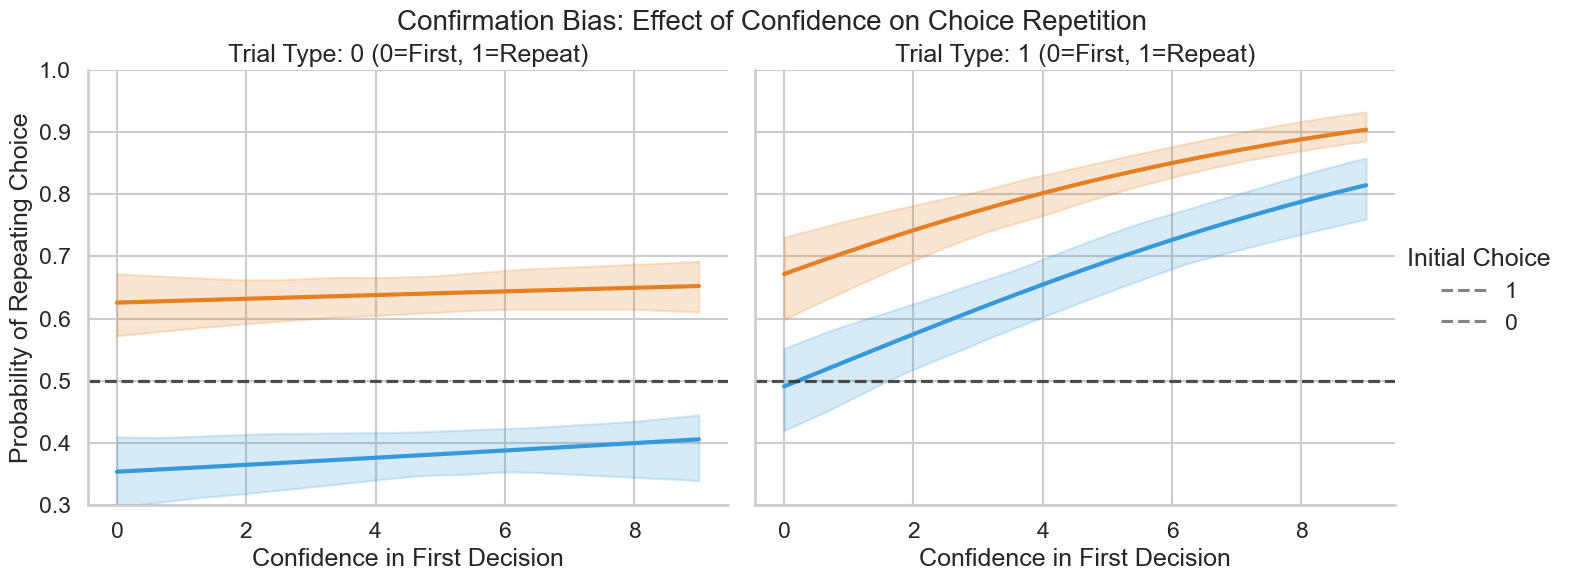

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SET THE STYLE ---
sns.set_theme(style="whitegrid", context="talk")
# Custom palette: Blue for Choice 0, Orange for Choice 1
palette = {'0': '#3498db', '1': '#e67e22'}

# --- 2. INITIALIZE THE FACETGRID ---
# col="nrep" splits the plots into two side-by-side panels
g = sns.FacetGrid(
    final_summary, 
    col="nrep", 
    hue="response1", 
    height=6, 
    aspect=1.2, 
    palette=palette
)

# --- 3. DRAW THE MEAN LINES ---
g.map(sns.lineplot, "Confidence1", "Mean_P_Repeat", linewidth=3)

# --- 4. DRAW THE CI RIBBONS ---
# We loop through each axis to manually add the shaded area
for (nrep_val, ax) in g.axes_dict.items():
    for resp_val in ['0', '1']:
        # Filter the data for this specific line
        subset = final_summary[
            (final_summary['nrep'] == nrep_val) & 
            (final_summary['response1'] == resp_val)
        ]
        
        # Draw the shaded ribbon
        ax.fill_between(
            subset['Confidence1'], 
            subset['CI_Lower'], 
            subset['CI_Upper'], 
            color=palette[resp_val], 
            alpha=0.2,
            label=f"Choice {resp_val} CI"
        )

# --- 5. FINISH & FORMAT ---
# Add a horizontal dashed line at 0.5 (Chance)
g.refline(y=0.5, linestyle="--", color="#333333", alpha=0.6)

# Improve labels and titles
g.set_axis_labels("Confidence in First Decision", "Probability of Repeating Choice")
g.set_titles("Trial Type: {col_name} (0=First, 1=Repeat)")
g.set(ylim=(0.3, 1.0)) # Focus on the relevant range

# Add a clean legend
g.add_legend(title="Initial Choice")
plt.subplots_adjust(top=0.88)
g.fig.suptitle('Confirmation Bias: Effect of Confidence on Choice Repetition', fontsize=20)

plt.show()

In [23]:
# --- 1. COLLAPSE ACROSS RESPONSES ---
# Average Choice 0 and Choice 1 results for every bootstrap iteration
collapsed_iter = boot_results_df.groupby(['Confidence1', 'nrep', 'boot_iter'])['P_Repeat'].mean().reset_index()

# --- 2. CALCULATE STATISTICS ---
# Calculate Mean and 95% CI across iterations
final_plot_df = collapsed_iter.groupby(['Confidence1', 'nrep'])['P_Repeat'].agg(
    Mean_P_Repeat='mean',
    CI_Lower=lambda x: np.percentile(x, 2.5),
    CI_Upper=lambda x: np.percentile(x, 97.5)
).reset_index()

# Friendly Labels for the Legend
final_plot_df['Condition'] = final_plot_df['nrep'].map({
    '0': 'Initial Presentation', 
    '1': 'Repeated (Confirmation Bias)'
})

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_5492/2306333361.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  collapsed_iter = boot_results_df.groupby(['Confidence1', 'nrep', 'boot_iter'])['P_Repeat'].mean().reset_index()
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_5492/2306333361.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_plot_df = collapsed_iter.groupby(['Confidence1', 'nrep'])['P_Repeat'].agg(


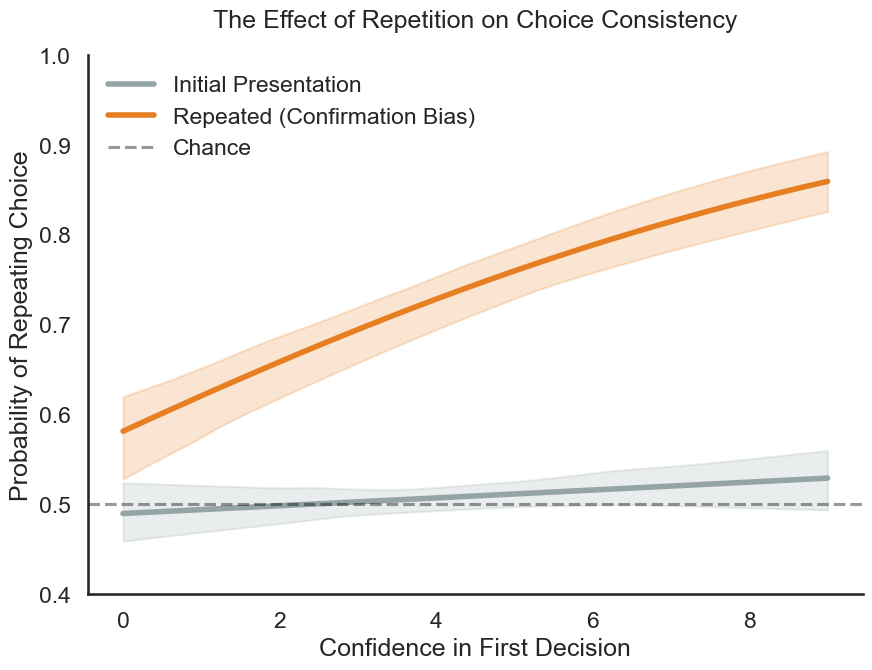

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="talk")
palette = {'Initial Presentation': '#95a5a6', 'Repeated (Confirmation Bias)': '#e67e22'}

plt.figure(figsize=(10, 7))

# Draw the lines and ribbons for both conditions
for condition in final_plot_df['Condition'].unique():
    subset = final_plot_df[final_plot_df['Condition'] == condition]
    
    # Line
    plt.plot(subset['Confidence1'], subset['Mean_P_Repeat'], 
             label=condition, color=palette[condition], linewidth=4)
    
    # Shaded CI
    plt.fill_between(subset['Confidence1'], subset['CI_Lower'], subset['CI_Upper'], 
                     color=palette[condition], alpha=0.2)

# --- FORMATTING ---
plt.axhline(0.5, linestyle="--", color="black", alpha=0.4, label="Chance")

plt.ylim(0.4, 1.0)
plt.xlabel("Confidence in First Decision")
plt.ylabel("Probability of Repeating Choice")
plt.title("The Effect of Repetition on Choice Consistency", fontsize=18, pad=20)

plt.legend(frameon=False)
sns.despine()

plt.show()

In [12]:
from tqdm import tqdm

In [365]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pymer4.models import Lmer
from tqdm import tqdm

# ---------------------------------------------------------
# 1. SETUP THE PREDICTION GRID (rDV = 0, nrep = 1)
# ---------------------------------------------------------
conf_range = np.linspace(df_CJ['Confidence1'].min(), df_CJ['Confidence1'].max(), 50)

grid = []
for conf in conf_range:
    for resp1 in [0, 1]:
        grid.append({
            'Confidence1': conf,
            'response1': resp1,
            'Previous_Response': 'Chose 1' if resp1 == 1 else 'Chose 0',
            'nrep': 1,
            'rDV': 0.0,
            'id_subj': df_CJ['id_subj'].iloc[0]
        })

pred_grid = pd.DataFrame(grid)

# Fix the R Factor bug
pred_grid['response1'] = pd.Categorical(pred_grid['response1'], categories=sorted(df_CJ['response1'].unique()))
pred_grid['nrep']      = pd.Categorical(pred_grid['nrep'],      categories=sorted(df_CJ['nrep'].unique()))
pred_grid['id_subj']   = pd.Categorical(pred_grid['id_subj'],   categories=sorted(df_CJ['id_subj'].unique()))

# ---------------------------------------------------------
# 2. GET THE OBSERVED PREDICTIONS
# ---------------------------------------------------------
obs_preds = np.array(md_CJ_full_confi_exp.predict(
    pred_grid, use_rfx=False, skip_data_checks=True, verify_predictions=False
))

pred_grid['Observed_P_1'] = obs_preds
pred_grid['Observed_P_Repeat'] = np.where(
    pred_grid['response1'] == 1,
    pred_grid['Observed_P_1'],
    1 - pred_grid['Observed_P_1']
)

# ---------------------------------------------------------
# 3. PERMUTATION LOOP
# ---------------------------------------------------------
n_perm = 100
perm_predictions = []
print(f"Starting {n_perm} permutation iterations...")

for i in tqdm(range(n_perm)):
    try:
        perm_df = df_CJ.copy()

        # Shuffle Responses within each subject
        perm_df['Responses'] = perm_df.groupby('id_subj')['Responses'].transform(
            lambda x: x.sample(frac=1).values
        )

        # Fit the null model
        perm_model = Lmer(
            "Responses ~ rDV * response1 * Confidence1 * nrep + (1|id_subj)",
            data=perm_df, family="binomial"
        )
        perm_model.fit(summarize=False, verbose=False)

        # Predict on our grid
        null_preds = np.array(perm_model.predict(
            pred_grid, use_rfx=False, skip_data_checks=True, verify_predictions=False
        ))

        null_p_repeat = np.where(pred_grid['response1'] == 1, null_preds, 1 - null_preds)
        perm_predictions.append(null_p_repeat)

    except Exception as e:
        print(f"\nIteration {i} failed: {e}")
        break

# ---------------------------------------------------------
# 4. PLOT
# ---------------------------------------------------------
if not perm_predictions:
    print("All permutations failed. Check the error above.")
else:
    perm_predictions = np.array(perm_predictions)
    pred_grid['Null_Lower'] = np.percentile(perm_predictions, 2.5,  axis=0)
    pred_grid['Null_Upper'] = np.percentile(perm_predictions, 97.5, axis=0)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(9, 6))
    colors = {0: '#e74c3c', 1: '#2ecc71'}

    for resp1 in [0, 1]:
        sub_df = pred_grid[pred_grid['response1'] == resp1].sort_values('Confidence1')

        plt.fill_between(
            sub_df['Confidence1'],
            sub_df['Null_Lower'],
            sub_df['Null_Upper'],
            color=colors[resp1], alpha=0.15,
            label=f'95% Null: Chose {resp1}'
        )
        plt.plot(
            sub_df['Confidence1'],
            sub_df['Observed_P_Repeat'],
            color=colors[resp1],
            linewidth=3,
            label=f'Observed: Chose {resp1}'
        )

    plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.6, label='Chance (0.5)')

    plt.title(
        'Observed Confirmation Bias vs. Permuted Null Distribution\n(nrep = 1, rDV = 0)',
        fontsize=14, pad=15
    )
    plt.xlabel('Confidence in Previous Choice (Confidence1)', fontsize=12)
    plt.ylabel('Probability of Repeating Response', fontsize=12)
    plt.ylim(0, 1)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='best')

    sns.despine()
    plt.tight_layout()
    plt.show()

Starting 100 permutation iterations...


  0%|          | 0/100 [00:00<?, ?it/s]/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "response1". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "nrep". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
  0%|          | 0/100 [00:08<?, ?it/s]

Model failed to converge with max|grad| = 0.00817587 (tol = 0.002, component 1) 

**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.


Iteration 0 failed: Error in `contrasts<-`(`*tmp*`, value = contr.funs[1 + isOF[nn]]) : 
  contrasts can be applied only to factors with 2 or more levels

All permutations failed. Check the error above.


## __Metaconfidence analyses__

Fitting only responses to the second repetition (because the full model is too complex to converge "Responses ~  rDV  * response1 * metad_eff * nrep + (1|id_subj)")

In [28]:
dat = df[(df.exp_ID == 'CJ') & (df.nrep == 1) ]

md_CJnrep_metad_exp = Lmer("Responses ~  rDV + metad_eff*response1 + (rDV|id_subj)", data=dat, family="binomial")
md_CJnrep_metad_exp.fit()
lmm_models['CJ_exp']['md_CJnrep_metad_exp'] = md_CJnrep_metad_exp
md_CJnrep_metad_exp.summary()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV+metad_eff*response1+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 6512	 Groups: {'id_subj': 37.0}

Log-likelihood: -2788.074 	 AIC: 5592.147

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.110  0.331
id_subj          rDV  2.847  1.687

                 IV1  IV2  Corr
id_subj  (Intercept)  rDV  0.14

Fixed effects:

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: Responses~rDV+metad_eff*response1+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 6512	 Groups: {'id_subj': 37.0}

Log-likelihood: -2788.074 	 AIC: 5592.147

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.110  0.331
id_subj          rDV  2.847  1.687

                 IV1  IV2  Corr
id_subj  (Intercept)  rDV  0.14

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),-0.762,-1.107,-0.418,0.176,0.467,0.331,0.659,0.318,0.249,0.397,-4.337,0.000,***
rDV,4.304,3.665,4.942,0.326,73.965,39.073,140.019,0.987,0.975,0.993,13.217,0.000,***
metad_eff,0.279,-0.287,0.846,0.289,1.322,0.750,2.330,0.569,0.429,0.700,0.966,0.334,
response1,2.620,2.295,2.946,0.166,13.742,9.925,19.028,0.932,0.908,0.950,15.782,0.000,***
metad_eff:response1,-0.892,-1.424,-0.361,0.271,0.410,0.241,0.697,0.291,0.194,0.411,-3.291,0.001,***


In [29]:
report_no_plot = generate_report(
    md_CJnrep_metad_exp, 
    title="Table 4: Mixed-Effects: Metacognitive efficiency (Mratio)",
    save_path="md_CJnrep_metad_exp.html",
    include_plot=False  # <-- The plot is turned off!
)

display(report_no_plot)

Predictor,Beta,SE,z,p-value,Sig
(Intercept),-0.762,0.176,-4.337,< .001,***
rDV,4.304,0.326,13.217,< .001,***
metad_eff,0.279,0.289,0.966,0.334,
response1,2.620,0.166,15.782,< .001,***
metad_eff × response1,-0.892,0.271,-3.291,< .001,***


In [58]:
import pandas as pd
import numpy as np

# 1. Identify the types in your training data
# We need to know if 'response1' was a string, int, or Categorical in 'dat'
resp_type = dat['response1'].dtype
subj_type = dat['id_subj'].dtype

# 2. Create the grid (re-using your logic)
metad_range = np.linspace(dat['metad_eff'].min(), dat['metad_eff'].max(), 100)
grid = []
for m in metad_range:
    for resp1 in dat['response1'].unique(): # Use values directly from training data
        grid.append({
            'metad_eff': m,
            'response1': resp1,
            'rDV': 0,
            'id_subj': dat['id_subj'].iloc[0], # Must be a subject that exists in 'dat'
            'Responses': 0 # Dummy column often required by R's predict.matrix
        })

pred_grid = pd.DataFrame(grid)

# 3. FORCE EXACT MATCHING
# If 'dat' used Categoricals, the grid MUST have the exact same categories/levels
if isinstance(resp_type, pd.CategoricalDtype):
    pred_grid['response1'] = pd.Categorical(pred_grid['response1'], 
                                            categories=dat['response1'].cat.categories)
else:
    pred_grid['response1'] = pred_grid['response1'].astype(resp_type)

if isinstance(subj_type, pd.CategoricalDtype):
    pred_grid['id_subj'] = pd.Categorical(pred_grid['id_subj'], 
                                          categories=dat['id_subj'].cat.categories)
else:
    pred_grid['id_subj'] = pred_grid['id_subj'].astype(subj_type)

# 4. Final attempt at the R predict
try:
    preds = md_CJnrep_metad_exp.predict(
        pred_grid, 
        use_rfx=False, 
        skip_data_checks=True, 
        verify_predictions=False
    )
    pred_grid['Prob_Choosing_1'] = np.array(preds)
    print("✅ Success! Type matching worked.")
except Exception as e:
    print(f"❌ Still failing: {e}")
    print("This confirms R is being strict about the Factor contrast matrix.")

✅ Success! Type matching worked.


In [61]:
# Group by metad_eff to get the average repetition probability across both response types
collapsed_grid = pred_grid.groupby('metad_eff')['P_Repeat'].mean().reset_index()

# If you want to include the raw data points from 'dat' for context:
# We calculate the actual repetition rate per subject/metad_eff bin
dat['is_repeat'] = (dat['Responses'] == dat['response1']).astype(int)

In [74]:
import numpy as np
import pandas as pd
from pymer4.models import Lmer
from tqdm import tqdm
import warnings

# --- 1. SETUP ---
n_boot = 100 # Set to 500+ for publication
unique_subjects = dat['id_subj'].unique()
metad_range = np.linspace(dat['metad_eff'].min(), dat['metad_eff'].max(), 50)

# Create the standard grid
grid_list = []
for m in metad_range:
    for resp1 in dat['response1'].unique():
        grid_list.append({'metad_eff': m, 'response1': resp1, 'rDV': 0, 'id_subj': unique_subjects[0]})
base_grid = pd.DataFrame(grid_list)

boot_results = []

print(f"Running {n_boot} Bootstrap iterations...")

# --- 2. LOOP ---
for i in tqdm(range(n_boot)):
    try:
        # A. Resample
        subs = np.random.choice(unique_subjects, size=len(unique_subjects), replace=True)
        boot_df = pd.concat([dat[dat['id_subj'] == s].assign(id_subj=f"b_{idx}") for idx, s in enumerate(subs)])
        
        # B. Fit
        model = Lmer("Responses ~ rDV + metad_eff * response1 + (rDV|id_subj)", data=boot_df, family="binomial")
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model.fit(summarize=False, verbose=False, control="optimizer='bobyqa'")
        
        # C. Predict (Using the Type-Sync logic)
        iter_grid = base_grid.copy()
        iter_grid['id_subj'] = pd.Categorical(iter_grid['id_subj'], categories=boot_df['id_subj'].unique())
        iter_grid['response1'] = pd.Categorical(iter_grid['response1'], categories=boot_df['response1'].unique())
        
        preds = model.predict(iter_grid, use_rfx=False, skip_data_checks=True, verify_predictions=False)
        iter_grid['P_1'] = np.array(preds)
        
        # D. Calculate P_Repeat
        iter_grid['P_Repeat'] = np.where(iter_grid['response1'].astype(str) == '1', 
                                         iter_grid['P_1'], 1 - iter_grid['P_1'])
        
        # E. MARGINALIZE: Average the 0 and 1 responses into a single value per metad_eff
        marginal_iter = iter_grid.groupby('metad_eff')['P_Repeat'].mean().reset_index()
        marginal_iter['boot_iter'] = i
        boot_results.append(marginal_iter)
        
    except Exception:
        continue

# --- 3. AGGREGATE ---
boot_df_final = pd.concat(boot_results)
final_summary = boot_df_final.groupby('metad_eff')['P_Repeat'].agg(
    Mean_P='mean',
    CI_Lower=lambda x: np.percentile(x, 2.5),
    CI_Upper=lambda x: np.percentile(x, 97.5)
).reset_index()

Running 100 Bootstrap iterations...


  0%|          | 0/100 [00:00<?, ?it/s]/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "response1". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
  1%|          | 1/100 [00:01<02:40,  1.62s/it]/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "response1". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
  2%|▏         | 2/100 [00:02<02:24,  1.47s/it]/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "response1". Fall back to st

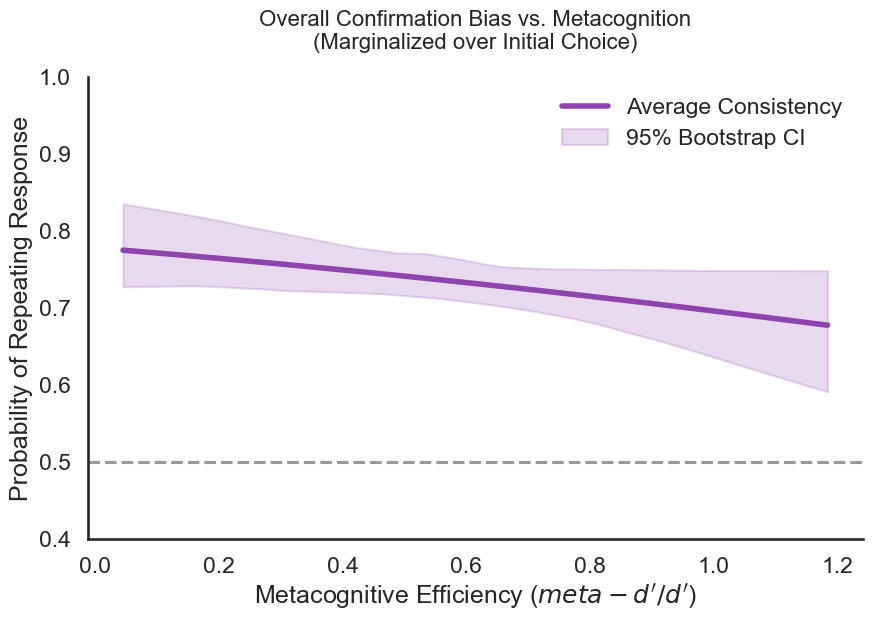

In [75]:

sns.set_theme(style="white", context="talk")
plt.figure(figsize=(10, 6))

# Plot the Mean Line
plt.plot(final_summary['metad_eff'], final_summary['Mean_P'], 
         color='#8e44ad', linewidth=4, label='Average Consistency')

# Plot the Shaded Confidence Interval
plt.fill_between(
    final_summary['metad_eff'], 
    final_summary['CI_Lower'], 
    final_summary['CI_Upper'], 
    color='#8e44ad', 
    alpha=0.2, 
    label='95% Bootstrap CI'
)

# Baseline reference (0.5 = No Bias)
plt.axhline(0.5, linestyle="--", color="black", alpha=0.4)

# Labels and Formatting
plt.xlabel("Metacognitive Efficiency ($meta-d'/d'$)")
plt.ylabel("Probability of Repeating Response")
plt.title("Overall Confirmation Bias vs. Metacognition\n(Marginalized over Initial Choice)", fontsize=16, pad=20)
plt.ylim(0.4, 1) # Focus on the area of interest

plt.legend(frameon=False)
sns.despine()

plt.show()

df_CJ = df[(df.exp_ID == 'CJ') ]
# [((dflong_CJ.nrep == 1))]
md_CJnrep_metad_acc_exp = Lmer("Responses ~  rDV  + response1 +  response1 *metad_eff + response1:metad_eff: accuracy1  + (rDV|id_subj)", data=df_CJ[df_CJ.nrep == 1], family="binomial")
md_CJnrep_metad_acc_exp.fit()

In [69]:
from scipy.stats import chi2
def likelihood_ratio_test(simple_model, complex_model):
    """
    Performs a likelihood ratio test between two fitted pymer4 models.

    Args:
        simple_model: The fitted simpler (nested) model object.
        complex_model: The fitted more complex model object.

    Returns:
        A dictionary containing the test results.
    """

    # 1. Get the log-likelihoods
    ll_simple = simple_model.logLike
    ll_complex = complex_model.logLike

    # 2. Get the number of parameters (k) for each model using AIC
    # AIC = 2k - 2LL  =>  k = (AIC + 2LL) / 2
    k_simple = (simple_model.AIC + 2 * ll_simple) / 2
    k_complex = (complex_model.AIC + 2 * ll_complex) / 2

    # 3. Calculate the test statistic and degrees of freedom
    chi2_stat = 2 * (ll_complex - ll_simple)
    df = k_complex - k_simple

    # 4. Calculate the p-value
    p_value = 1 - chi2.cdf(chi2_stat, df)
    
    # Ensure results are serializable and clean
    results = {
        "Simple Model LL": ll_simple,
        "Complex Model LL": ll_complex,
        "Chi-squared Stat": chi2_stat,
        "Degrees of Freedom": df,
        "p-value": p_value
    }
    
    print(f"Chi-squared: {chi2_stat:.3f}, df: {df:.0f}, p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Result: The complex model is a significantly better fit.")
    else:
        print("Result: The complex model is NOT a significantly better fit.")
        
    return results

# --- How to use it ---

# 1. Make sure both models are fitted
# simple_model.fit()
# complex_model.fit()

# 2. Run the test
# test_results = likelihood_ratio_test(simple_model, complex_model)

In [201]:
likelihood_ratio_test(md0_CJnrep_metad_acc_exp, md1_CJnrep_metad_acc_exp )

Chi-squared: 2.886, df: 1, p-value: 0.0894
Result: The complex model is NOT a significantly better fit.


{'Simple Model LL': np.float64(-2663.6788996645823),
 'Complex Model LL': np.float64(-2662.2359802213373),
 'Chi-squared Stat': np.float64(2.8858388864900917),
 'Degrees of Freedom': np.float64(1.0),
 'p-value': np.float64(0.08936145342713042)}

__Modelling accuracy changes as a function of metacognitive efficiency__


The model is singular because participants accuracy is highly similar

In [65]:
df_CJ = df[df['exp_ID'] == 'CJ']
CJnrep0_metad_acc_exp = Lmer("accuracy ~  nrep* metad_eff   + (rDV|id_subj)", data=df_CJ, family="binomial")
CJnrep0_metad_acc_exp.fit()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: accuracy~nrep*metad_eff+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13024	 Groups: {np.str_('id_subj'): np.float64(37.0)}

Log-likelihood: -7395.716 	 AIC: 14805.432

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.003  0.056
id_subj          rDV  2.680  1.637

                 IV1  IV2   Corr
id_subj  (Intercept)  rDV -0.158

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.959,0.802,1.116,0.080,2.609,2.230,3.053,0.723,0.690,0.753,11.975,0.000,***
nrep,0.071,-0.116,0.258,0.095,1.074,0.891,1.294,0.518,0.471,0.564,0.745,0.457,
metad_eff,0.033,-0.200,0.267,0.119,1.034,0.819,1.305,0.508,0.450,0.566,0.279,0.780,
nrep:metad_eff,0.090,-0.222,0.403,0.160,1.095,0.801,1.497,0.523,0.445,0.599,0.566,0.571,


In [66]:
df_CJ = df[df['exp_ID'] == 'CJ']
CJnrep1_metad_acc_exp = Lmer("accuracy ~  nrep* metad_eff + accuracy1   + (rDV|id_subj)", data=df_CJ, family="binomial")
CJnrep1_metad_acc_exp.fit()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: accuracy~nrep*metad_eff+accuracy1+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13024	 Groups: {np.str_('id_subj'): np.float64(37.0)}

Log-likelihood: -7015.118 	 AIC: 14046.236

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.000  0.012
id_subj          rDV  2.493  1.579

                 IV1  IV2  Corr
id_subj  (Intercept)  rDV   1.0

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.111,-0.050,0.271,0.082,1.117,0.951,1.311,0.528,0.488,0.567,1.351,0.177,
nrep,0.122,-0.071,0.315,0.099,1.130,0.931,1.371,0.530,0.482,0.578,1.238,0.216,
metad_eff,0.017,-0.209,0.244,0.116,1.017,0.811,1.276,0.504,0.448,0.561,0.149,0.881,
accuracy1,1.197,1.112,1.282,0.043,3.311,3.042,3.605,0.768,0.753,0.783,27.635,0.000,***
nrep:metad_eff,0.109,-0.215,0.432,0.165,1.115,0.807,1.540,0.527,0.447,0.606,0.659,0.510,


In [31]:
df_CJ = df[df['exp_ID'] == 'CJ']
CJnrep2_metad_acc_exp = Lmer("accuracy ~  nrep* metad_eff * accuracy1   + (rDV|id_subj)", data=df_CJ, family="binomial")
CJnrep2_metad_acc_exp.fit()

Model failed to converge with max|grad| = 0.00481987 (tol = 0.002, component 1) 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: accuracy~nrep*metad_eff*accuracy1+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13024	 Groups: {'id_subj': 37.0}

Log-likelihood: -6714.582 	 AIC: 13451.164

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.002  0.046
id_subj          rDV  2.093  1.447

                 IV1  IV2  Corr
id_subj  (Intercept)  rDV -0.08

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.825,0.568,1.081,0.131,2.281,1.765,2.948,0.695,0.638,0.747,6.303,0.000,***
nrep,-1.499,-1.831,-1.167,0.170,0.223,0.160,0.311,0.183,0.138,0.237,-8.841,0.000,***
metad_eff,0.071,-0.339,0.481,0.209,1.074,0.712,1.618,0.518,0.416,0.618,0.339,0.734,
accuracy1,0.167,-0.121,0.455,0.147,1.182,0.886,1.576,0.542,0.470,0.612,1.137,0.256,
nrep:metad_eff,0.569,0.017,1.121,0.281,1.767,1.018,3.067,0.639,0.504,0.754,2.022,0.043,*
nrep:accuracy1,2.652,2.227,3.076,0.217,14.180,9.275,21.678,0.934,0.903,0.956,12.244,0.000,***
metad_eff:accuracy1,-0.054,-0.534,0.426,0.245,0.947,0.586,1.531,0.486,0.370,0.605,-0.222,0.825,
nrep:metad_eff:accuracy1,-0.887,-1.589,-0.185,0.358,0.412,0.204,0.831,0.292,0.169,0.454,-2.477,0.013,*


In [32]:
report_no_plot = generate_report(
    CJnrep2_metad_acc_exp, 
    title="Table 5: Mixed-Effects Accuracy × Mratio",
    save_path="CJnrep2_metad_acc_exp.html",
    include_plot=False  # <-- The plot is turned off!
)

display(report_no_plot)

Predictor,Beta,SE,z,p-value,Sig
(Intercept),0.825,0.131,6.303,< .001,***
nrep,-1.499,0.170,-8.841,< .001,***
metad_eff,0.071,0.209,0.339,0.734,
accuracy1,0.167,0.147,1.137,0.256,
nrep × metad_eff,0.569,0.281,2.022,0.043,*
nrep × accuracy1,2.652,0.217,12.244,< .001,***
metad_eff × accuracy1,-0.054,0.245,-0.222,0.825,
nrep × metad_eff × accuracy1,-0.887,0.358,-2.477,0.013,*


Contrasting models

In [72]:
likelihood_ratio_test(CJnrep0_metad_acc_exp, CJnrep1_metad_acc_exp  )

Chi-squared: 761.197, df: 1, p-value: 0.0000
Result: The complex model is a significantly better fit.


{'Simple Model LL': np.float64(-7395.716041510868),
 'Complex Model LL': np.float64(-7015.11775060647),
 'Chi-squared Stat': np.float64(761.1965818087974),
 'Degrees of Freedom': np.float64(1.0),
 'p-value': np.float64(0.0)}

In [71]:
likelihood_ratio_test(CJnrep1_metad_acc_exp, CJnrep2_metad_acc_exp  )

Chi-squared: 601.072, df: 3, p-value: 0.0000
Result: The complex model is a significantly better fit.


{'Simple Model LL': np.float64(-7015.11775060647),
 'Complex Model LL': np.float64(-6714.581893990382),
 'Chi-squared Stat': np.float64(601.0717132321752),
 'Degrees of Freedom': np.float64(3.0),
 'p-value': np.float64(0.0)}

In [58]:
df_CJ = df[df['exp_ID'] == 'CJ']
CJnrep_metad_acc_exp = Lmer("accuracy ~  nrep* metad_eff *accuracy1  + (rDV|id_subj)", data=df_CJ, family="binomial")
CJnrep_metad_acc_exp.fit()

Model failed to converge with max|grad| = 0.00481987 (tol = 0.002, component 1) 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: accuracy~nrep*metad_eff*accuracy1+(rDV|id_subj)

Family: binomial	 Inference: parametric

Number of observations: 13024	 Groups: {np.str_('id_subj'): np.float64(37.0)}

Log-likelihood: -6714.582 	 AIC: 13451.164

Random effects:

                Name    Var    Std
id_subj  (Intercept)  0.002  0.046
id_subj          rDV  2.093  1.447

                 IV1  IV2  Corr
id_subj  (Intercept)  rDV -0.08

Fixed effects:



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.825,0.568,1.081,0.131,2.281,1.765,2.948,0.695,0.638,0.747,6.303,0.000,***
nrep,-1.499,-1.831,-1.167,0.170,0.223,0.160,0.311,0.183,0.138,0.237,-8.841,0.000,***
metad_eff,0.071,-0.339,0.481,0.209,1.074,0.712,1.618,0.518,0.416,0.618,0.339,0.734,
accuracy1,0.167,-0.121,0.455,0.147,1.182,0.886,1.576,0.542,0.470,0.612,1.137,0.256,
nrep:metad_eff,0.569,0.017,1.121,0.281,1.767,1.018,3.067,0.639,0.504,0.754,2.022,0.043,*
nrep:accuracy1,2.652,2.227,3.076,0.217,14.180,9.275,21.678,0.934,0.903,0.956,12.244,0.000,***
metad_eff:accuracy1,-0.054,-0.534,0.426,0.245,0.947,0.586,1.531,0.486,0.370,0.605,-0.222,0.825,
nrep:metad_eff:accuracy1,-0.887,-1.589,-0.185,0.358,0.412,0.204,0.831,0.292,0.169,0.454,-2.477,0.013,*


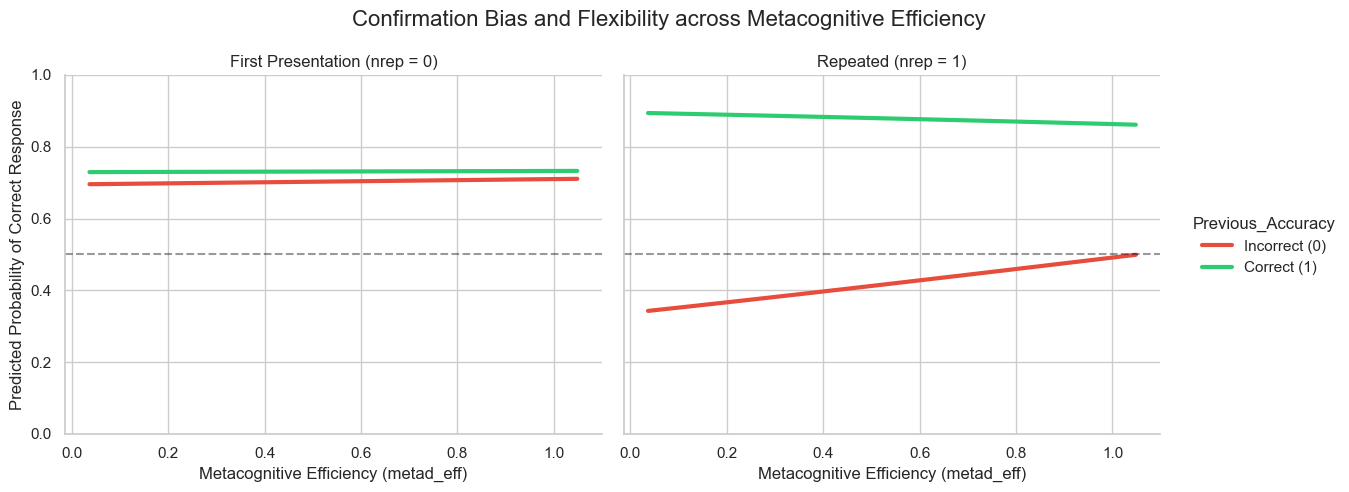

In [59]:


# 1. Generate a continuous range of metad_eff values for the x-axis
# We'll span from -2 SD to +2 SD to cover the vast majority of your participants
metad_mean = df_CJ['metad_eff'].mean()
metad_sd = df_CJ['metad_eff'].std()
metad_range = np.linspace(metad_mean - (2 * metad_sd), metad_mean + (2 * metad_sd), 50)

# 2. Create the prediction grid
grid = []
for metad_val in metad_range:
    for acc1 in [0, 1]:  # Previous accuracy: Incorrect vs Correct
        for nrep_val in [0, 1]:  # Sequence: First presentation vs Repetition
            grid.append({
                'metad_eff': metad_val,
                'accuracy1': acc1,
                'Previous_Accuracy': 'Correct (1)' if acc1 == 1 else 'Incorrect (0)',
                'nrep': nrep_val,
                'Repetition': 'First Presentation (nrep = 0)' if nrep_val == 0 else 'Repeated (nrep = 1)',
                # pymer4 requires the grouping variable to be present in the prediction data
                'id_subj': df_CJ['id_subj'].iloc[0] 
            })

pred_grid = pd.DataFrame(grid)

# 3. Generate predictions and convert from R FloatVector to Python numpy array
predictions = np.array(CJnrep_metad_acc_exp.predict(
    pred_grid, 
    use_rfx=False, 
    skip_data_checks=True,
    verify_predictions=False
))

# 4. Assign predictions directly (assuming pymer4 is returning probabilities)
pred_grid['Predicted_Probability'] = predictions

# 5. Plot the model predictions using a continuous line plot
sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=pred_grid, 
    x='metad_eff', 
    y='Predicted_Probability', 
    hue='Previous_Accuracy', 
    col='Repetition', 
    kind='line', 
    palette=['#e74c3c', '#2ecc71'], # Red for incorrect, Green for correct
    height=5, 
    aspect=1.2,
    linewidth=3
)

# --- NEW: Add the horizontal reference line at 0.5 (chance level) ---
g.refline(y=0.5, linestyle="--", color="black", alpha=0.4)

# Formatting the plot
g.set_axis_labels("Metacognitive Efficiency (metad_eff)", "Predicted Probability of Correct Response")
g.set_titles("{col_name}")
g.set(ylim=(0, 1)) # Probabilities are strictly between 0 and 1
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Confirmation Bias and Flexibility across Metacognitive Efficiency', fontsize=16)

plt.show()

Starting 100 bootstrap iterations... This might take a few minutes!


  0%|          | 0/100 [00:00<?, ?it/s]/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(
  1%|          | 1/100 [00:11<18:21, 11.12s/it]

Model failed to converge with max|grad| = 0.00216523 (tol = 0.002, component 1) 



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(
  2%|▏         | 2/100 [00:21<17:54, 10.97s/it]

Model failed to converge with max|grad| = 0.015362 (tol = 0.002, component 1) 



...

boundary (singular) fit: see help('isSingular') 



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(
 99%|█████████▉| 99/100 [49:19<00:15, 15.43s/it]

Model failed to converge with max|grad| = 0.00542323 (tol = 0.002, component 1) 



/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(
100%|██████████| 100/100 [49:26<00:00, 29.66s/it]

Model failed to converge with max|grad| = 0.00429712 (tol = 0.002, component 1) 



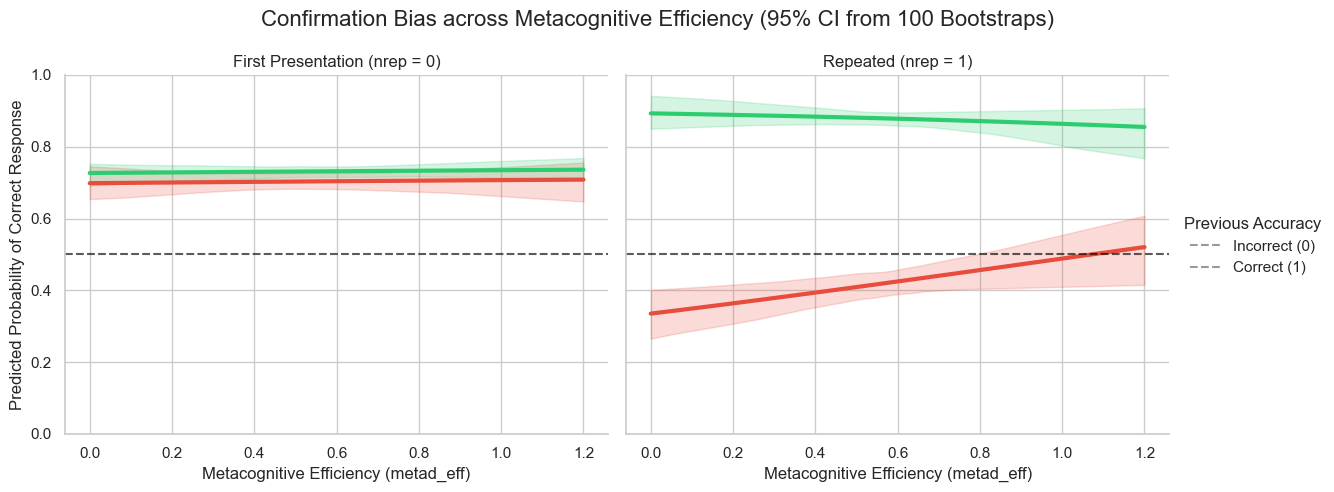

In [63]:

# 1. Generate the prediction grid with a continuous metad_eff range
metad_mean = df_CJ['metad_eff'].mean()
metad_sd = df_CJ['metad_eff'].std()
#metad_range = np.linspace(metad_mean - (2 * metad_sd), metad_mean + (2.5 * metad_sd), 50)
metad_range = np.linspace(0,1.2, 50)


grid = []
for metad_val in metad_range:
    for acc1 in [0, 1]:  
        for nrep_val in [0, 1]:  
            grid.append({
                'metad_eff': metad_val,
                'accuracy1': acc1,
                'Previous_Accuracy': 'Correct (1)' if acc1 == 1 else 'Incorrect (0)',
                'nrep': nrep_val,
                'Repetition': 'First Presentation (nrep = 0)' if nrep_val == 0 else 'Repeated (nrep = 1)',
                'id_subj': df_CJ['id_subj'].iloc[0] # Dummy subject required for pymer4 predictions
            })
            
pred_grid = pd.DataFrame(grid)

# 2. Bootstrapping Setup
n_boot = 100  # Start with 100 for testing. For a final publication plot, change to 500 or 1000.
boot_predictions = []
unique_subjects = df_CJ['id_subj'].unique()

print(f"Starting {n_boot} bootstrap iterations... This might take a few minutes!")

# 3. The Bootstrap Loop
for i in tqdm(range(n_boot)):
    try:
        # A. Resample subjects with replacement (Cluster-level bootstrap)
        boot_subjs = np.random.choice(unique_subjects, size=len(unique_subjects), replace=True)
        
        # B. Reconstruct the dataset 
        boot_df_list = []
        for new_id, subj in enumerate(boot_subjs):
            subj_data = df_CJ[df_CJ['id_subj'] == subj].copy()
            # Crucial: rename the subject ID so pymer4 doesn't merge identical subjects
            subj_data['id_subj'] = f"boot_{new_id}" 
            boot_df_list.append(subj_data)
        
        boot_df = pd.concat(boot_df_list)
        
        # C. Fit the model on the bootstrapped data
        boot_model = Lmer("accuracy ~ nrep * metad_eff * accuracy1 + (rDV|id_subj)", data=boot_df, family="binomial")
        boot_model.fit(summarize=False, verbose=False) # Suppress the giant printouts
        
        # D. Predict directly on our grid (pymer4 is already returning final probabilities here)
        preds = np.array(boot_model.predict(pred_grid, use_rfx=False, skip_data_checks=True, verify_predictions=False))
        
        # Append the raw probabilities directly (NO sigmoid math needed!)
        boot_predictions.append(preds)
        
    except Exception as e:
        # If a single bootstrap sample fails to converge, skip it so the loop doesn't crash
        pass

# 4. Calculate the 95% Confidence Intervals from the bootstrap distribution
# Convert list of arrays into a 2D numpy matrix
boot_predictions = np.array(boot_predictions) 

# Get the 2.5th (lower) and 97.5th (upper) percentiles for the 95% CI
pred_grid['CI_Lower'] = np.percentile(boot_predictions, 2.5, axis=0)
pred_grid['CI_Upper'] = np.percentile(boot_predictions, 97.5, axis=0)
# Get the mean prediction for the solid line
pred_grid['Predicted_Probability'] = np.mean(boot_predictions, axis=0) 

# 5. Plotting the results
sns.set_theme(style="whitegrid")
colors = {'Incorrect (0)': '#e74c3c', 'Correct (1)': '#2ecc71'}

# Set up the side-by-side FacetGrid
g = sns.FacetGrid(
    pred_grid, 
    col="Repetition", 
    hue="Previous_Accuracy", 
    height=5, 
    aspect=1.2, 
    palette=colors
)

# Draw the solid lines
g.map(sns.lineplot, "metad_eff", "Predicted_Probability", linewidth=3)

# Draw the Confidence Interval ribbons
for ax, (nrep_name, ax_data) in zip(g.axes.flat, pred_grid.groupby('Repetition')):
    for acc_val, color in colors.items():
        sub_data = ax_data[ax_data['Previous_Accuracy'] == acc_val]
        ax.fill_between(
            sub_data['metad_eff'], 
            sub_data['CI_Lower'], 
            sub_data['CI_Upper'], 
            color=color, 
            alpha=0.2 # 0.2 transparency so overlapping ribbons are visible
        )

# Add the horizontal reference line for chance accuracy (0.5)
g.refline(y=0.5, linestyle="--", color="black", alpha=0.4)

# Formatting labels and limits
g.set_axis_labels("Metacognitive Efficiency (metad_eff)", "Predicted Probability of Correct Response")
g.set_titles("{col_name}")
g.set(ylim=(0, 1.0)) # Lock y-axis from 0 to 1
g.add_legend(title="Previous Accuracy")
plt.subplots_adjust(top=0.85)
g.fig.suptitle(f'Confirmation Bias across Metacognitive Efficiency (95% CI from {n_boot} Bootstraps)', fontsize=16)

plt.show()

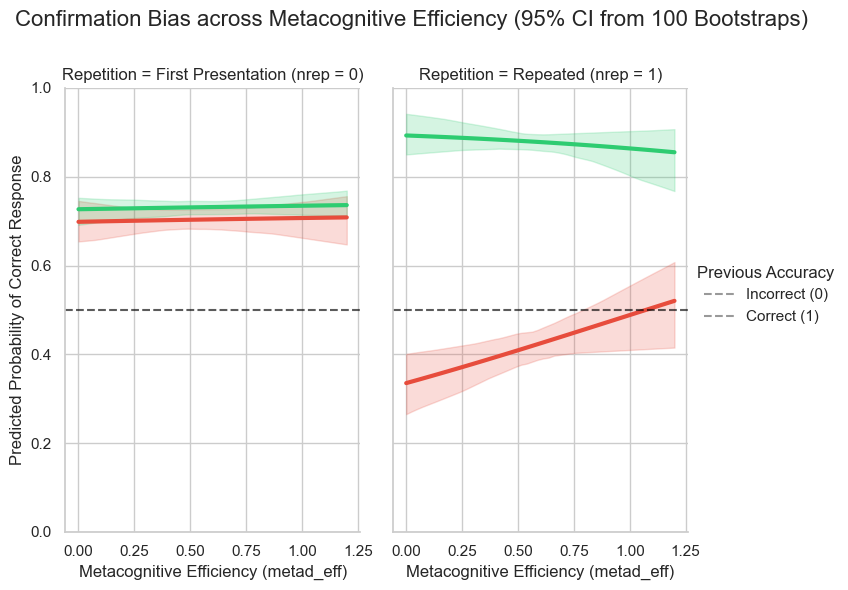

In [64]:

# 5. Plotting (Same logic as before, using our new CI columns)
sns.set_theme(style="whitegrid")
colors = {'Incorrect (0)': '#e74c3c', 'Correct (1)': '#2ecc71'}

g = sns.FacetGrid(pred_grid, col="Repetition", hue="Previous_Accuracy", height=6, aspect=0.6, palette=colors)
g.map(sns.lineplot, "metad_eff", "Predicted_Probability", linewidth=3)

for ax, (nrep_name, ax_data) in zip(g.axes.flat, pred_grid.groupby('Repetition')):
    for acc_val, color in colors.items():
        sub_data = ax_data[ax_data['Previous_Accuracy'] == acc_val]
        ax.fill_between(
            sub_data['metad_eff'], 
            sub_data['CI_Lower'], 
            sub_data['CI_Upper'], 
            color=color, 
            alpha=0.2 
        )
        
g.refline(y=0.5, linestyle="--", color="black", alpha=0.4)
g.set_axis_labels("Metacognitive Efficiency (metad_eff)", "Predicted Probability of Correct Response")
g.set(ylim=(0, 1))
g.add_legend(title="Previous Accuracy")
plt.subplots_adjust(top=0.85)
g.fig.suptitle(f'Confirmation Bias across Metacognitive Efficiency (95% CI from {n_boot} Bootstraps)', fontsize=16)

plt.show()

ONLY NREP= 1

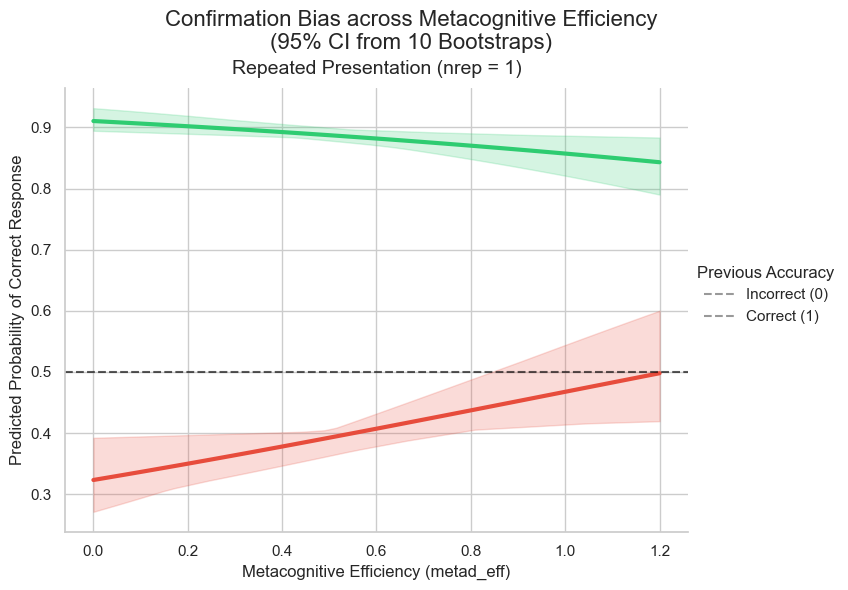

In [75]:
# 5. Plotting (Filtered for nrep = 1)
sns.set_theme(style="whitegrid")
colors = {'Incorrect (0)': '#e74c3c', 'Correct (1)': '#2ecc71'}

# --- CHANGE: Filter for only Repeated trials (nrep=1) ---
# We use .astype(str) just in case nrep was stored as an integer
pred_grid_filtered = pred_grid[pred_grid['nrep'].astype(str) == '1'].copy()

# --- CHANGE: Removed col="Repetition" as we only have one panel now ---
g = sns.FacetGrid(
    pred_grid_filtered, 
    hue="Previous_Accuracy", 
    height=6, 
    aspect=1.2, # Made it wider since it's a single plot
    palette=colors
)

g.map(sns.lineplot, "metad_eff", "Predicted_Probability", linewidth=3)

# Iterate over the single axis to draw ribbons
ax = g.ax 
for acc_val, color in colors.items():
    sub_data = pred_grid_filtered[pred_grid_filtered['Previous_Accuracy'] == acc_val]
    ax.fill_between(
        sub_data['metad_eff'], 
        sub_data['CI_Lower'], 
        sub_data['CI_Upper'], 
        color=color, 
        alpha=0.2 
    )
        
g.refline(y=0.5, linestyle="--", color="black", alpha=0.4)
g.set_axis_labels("Metacognitive Efficiency (metad_eff)", "Predicted Probability of Correct Response")

# --- CHANGE: Updated title to reflect it's only Repeated Trials ---
plt.title("Repeated Presentation (nrep = 1)", fontsize=14, pad=10)

g.add_legend(title="Previous Accuracy")
plt.subplots_adjust(top=0.85)
g.fig.suptitle(f'Confirmation Bias across Metacognitive Efficiency\n(95% CI from {n_boot} Bootstraps)', fontsize=16)

plt.show()

In [ ]:
INTENTADO CREAR UN PANEL CON TODO. BUSCA LOS OUTPUTS Y GENERALOS

# SAVING DATA FOR PLOTTING

In [98]:
# Save Panel A data (Confidence & Repetition)
final_plot_df.to_csv('./all_data_CSV/plot_CJ_confidence_repeat.csv', index=False)
final_summary.to_csv('./all_data_CSV/plot_CJ_metad_repeat.csv', index=False)
pred_grid.to_csv('./all_data_CSV/plot_CJ_metad_accuracy.csv', index=False)


✅ Data reloaded successfully.


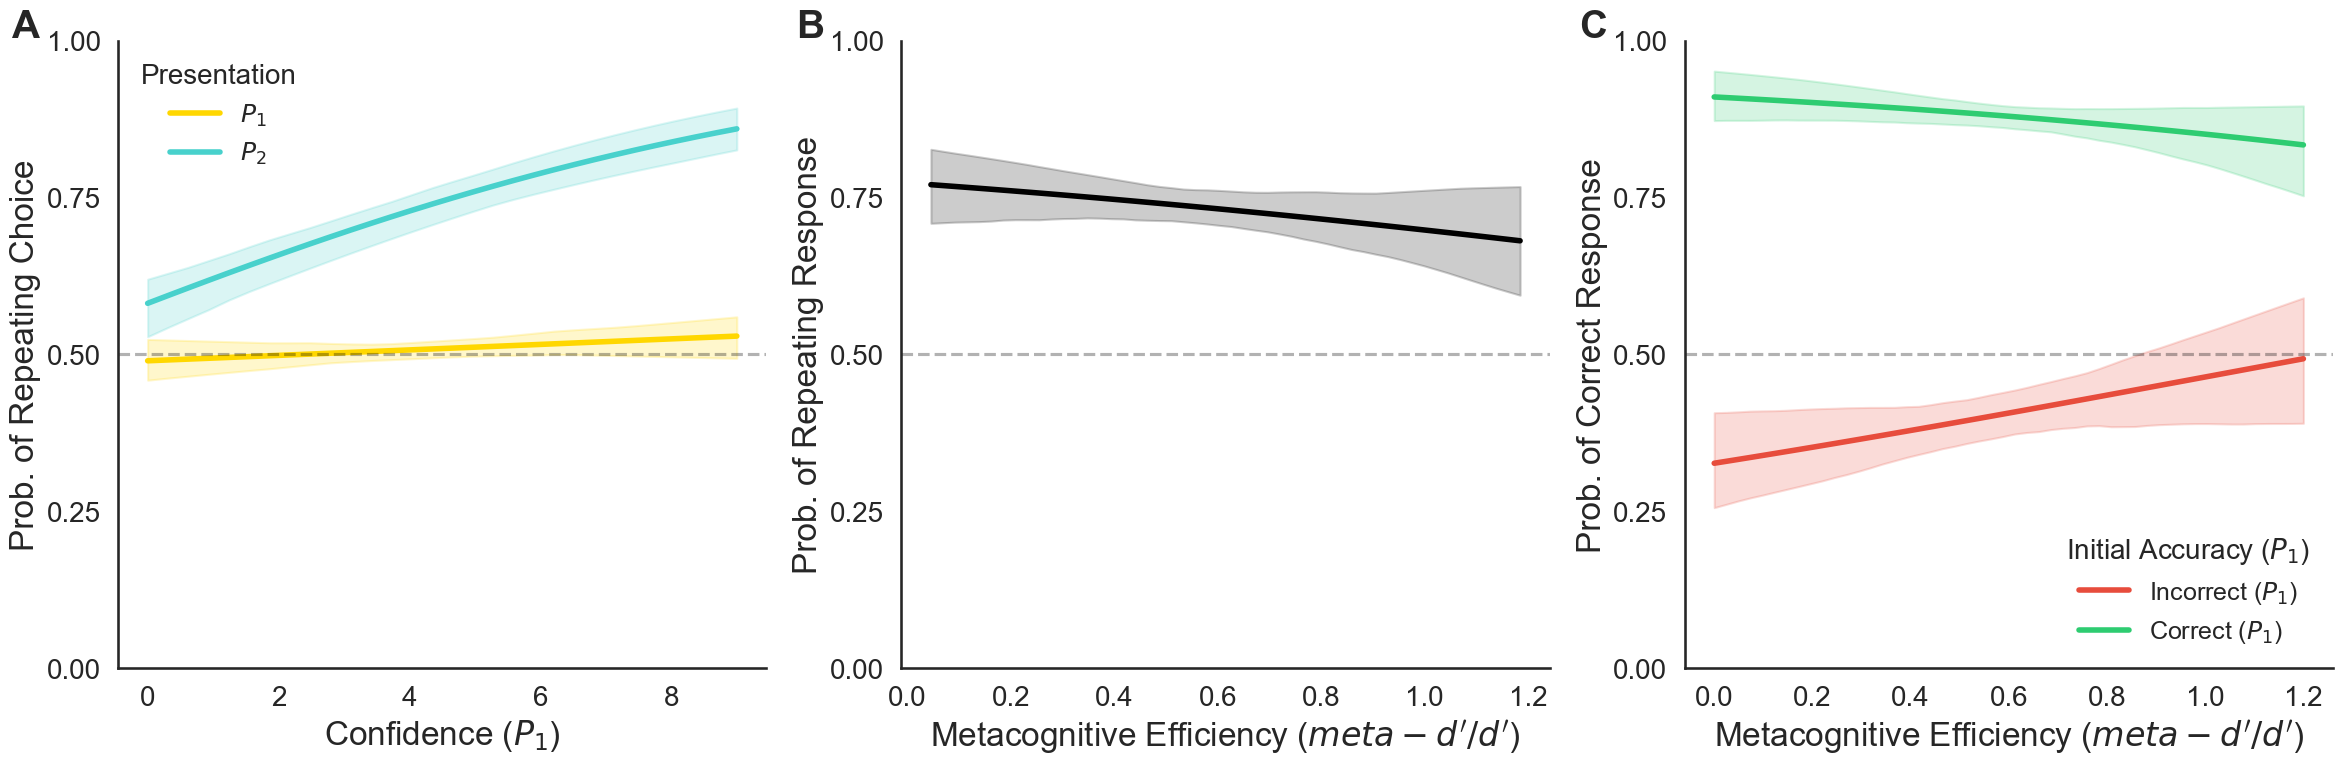

In [99]:
# --- 1. RELOAD THE DATA ---
# Ensure the path matches where you saved the files
final_plot_df = pd.read_csv('./all_data_CSV/plot_CJ_confidence_repeat.csv')
final_summary = pd.read_csv('./all_data_CSV/plot_CJ_metad_repeat.csv')
pred_grid = pd.read_csv('./all_data_CSV/plot_CJ_metad_accuracy.csv')

print("✅ Data reloaded successfully.")

# --- 2. SETUP FIGURE & GLOBAL STYLE ---
sns.set_theme(style="white", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
plt.subplots_adjust(wspace=0.3, top=0.9) 

# Font & Visual Settings
LBL_FONT = 24
TIC_FONT = 20
LEG_FONT = 18
PANEL_FONT = 28
y_ticks = [0, 0.25, 0.5, 0.75, 1.0]

# Specific Palettes & LaTeX Mappings
palette_rep = {'$P_1$': 'gold', '$P_2$': 'mediumturquoise'}
map_rep = {'Initial Presentation': '$P_1$', 'Repeated (Confirmation Bias)': '$P_2$'}

color_metad_bias = 'black' 

colors_acc = {'Incorrect ($P_1$)': '#e74c3c', 'Correct ($P_1$)': '#2ecc71'}
map_acc = {'0': 'Incorrect ($P_1$)', '1': 'Correct ($P_1$)'}

# ------------------------------------------------------------------
# PANEL A: Confidence & Choice Consistency
# ------------------------------------------------------------------
ax = axes[0]
for old_cond, new_label in map_rep.items():
    subset = final_plot_df[final_plot_df['Condition'] == old_cond]
    if not subset.empty:
        ax.plot(subset['Confidence1'], subset['Mean_P_Repeat'], 
                label=new_label, color=palette_rep[new_label], linewidth=4)
        ax.fill_between(subset['Confidence1'], subset['CI_Lower'], subset['CI_Upper'], 
                         color=palette_rep[new_label], alpha=0.2)

ax.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax.set_yticks(y_ticks)
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelsize=TIC_FONT)
ax.set_xlabel("Confidence ($P_1$)", fontsize=LBL_FONT)
ax.set_ylabel("Prob. of Repeating Choice", fontsize=LBL_FONT)
ax.legend(title="Presentation", fontsize=LEG_FONT, title_fontsize=LEG_FONT+2, frameon=False, loc='upper left')

# ------------------------------------------------------------------
# PANEL B: Metacognition & Global Bias
# ------------------------------------------------------------------
ax = axes[1]
ax.plot(final_summary['metad_eff'], final_summary['Mean_P'], 
         color=color_metad_bias, linewidth=4, label='Average Consistency')
ax.fill_between(final_summary['metad_eff'], final_summary['CI_Lower'], 
                 final_summary['CI_Upper'], color=color_metad_bias, alpha=0.2)

ax.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax.set_yticks(y_ticks)
ax.set_ylim(0, 1) 
ax.tick_params(axis='both', labelsize=TIC_FONT)
ax.set_xlabel("Metacognitive Efficiency ($meta-d'/d'$)", fontsize=LBL_FONT)
ax.set_ylabel("Prob. of Repeating Response", fontsize=LBL_FONT)

# ------------------------------------------------------------------
# PANEL C: Metacognition & Accuracy (Trial 2)
# ------------------------------------------------------------------
ax = axes[2]
# Filter for nrep=1 if the column exists
p_grid_filt = pred_grid[pred_grid['nrep'].astype(str) == '1'].copy() if 'nrep' in pred_grid.columns else pred_grid.copy()
label_col = 'Previous_Accuracy' if 'Previous_Accuracy' in p_grid_filt.columns else 'accuracy1'

for old_val, new_label in map_acc.items():
    sub_data = p_grid_filt[p_grid_filt[label_col].astype(str).str.contains(str(old_val))]
    if not sub_data.empty:
        y_col = 'Predicted_Probability' if 'Predicted_Probability' in sub_data.columns else 'Mean_Prob'
        ax.plot(sub_data['metad_eff'], sub_data[y_col], 
                color=colors_acc[new_label], linewidth=4, label=new_label)
        ax.fill_between(sub_data['metad_eff'], sub_data['CI_Lower'], 
                         sub_data['CI_Upper'], color=colors_acc[new_label], alpha=0.2)

ax.axhline(0.5, linestyle="--", color="black", alpha=0.3)
ax.set_yticks(y_ticks)
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelsize=TIC_FONT)
ax.set_xlabel("Metacognitive Efficiency ($meta-d'/d'$)", fontsize=LBL_FONT)
ax.set_ylabel("Prob. of Correct Response", fontsize=LBL_FONT)
ax.legend(title="Initial Accuracy ($P_1$)", fontsize=LEG_FONT, title_fontsize=LEG_FONT+2, frameon=False, loc='lower right')

# --- 3. ADD PANEL INDEX CHARACTERS (A, B, C) ---
for i, ax in enumerate(axes):
    ax.text(-0.12, 1.05, ['A', 'B', 'C'][i], transform=ax.transAxes, 
            fontsize=PANEL_FONT, fontweight='bold', va='top', ha='right')

# --- FINAL FORMATTING ---
sns.despine()
plt.tight_layout()

# Optional: Save the figure in high resolution
# plt.savefig('Confirmation_Bias_Metacognition_3Panel.pdf', dpi=300, bbox_inches='tight')

plt.show()

Organizing coefficients for plotting

In [123]:
md_stim_coefs = lmm_models['CJ_exp']['md_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_stim_coefs.reset_index(inplace = True)
md_stim_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)


md_dvdiff_coefs = lmm_models['CJ_exp']['md_dvdiff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_dvdiff_coefs.reset_index(inplace = True)
md_dvdiff_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)

md_anglediff_coefs = lmm_models['CJ_exp']['md_anglediff_stim_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_anglediff_coefs.reset_index(inplace = True)
md_anglediff_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)

stim_models = [md_dvdiff_coefs, md_anglediff_coefs]

md_CJ_rep_coefs = lmm_models['CJ_exp']['md_CJ_rep_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_CJ_rep_coefs.reset_index(inplace = True)
md_CJ_rep_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)



md_CJ_coefs = lmm_models['CJ_exp']['md_CJ_exp'].coefs[['Estimate','2.5_ci','97.5_ci']]
md_CJ_coefs.reset_index(inplace = True)
md_CJ_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)


/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/1098127985.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_stim_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/1098127985.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  md_dvdiff_coefs.rename(columns = {'index' : 'parameter'}, inplace = True)
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/1098127985.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pan

/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3911570660.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3911570660.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3911570660.py:10: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfv

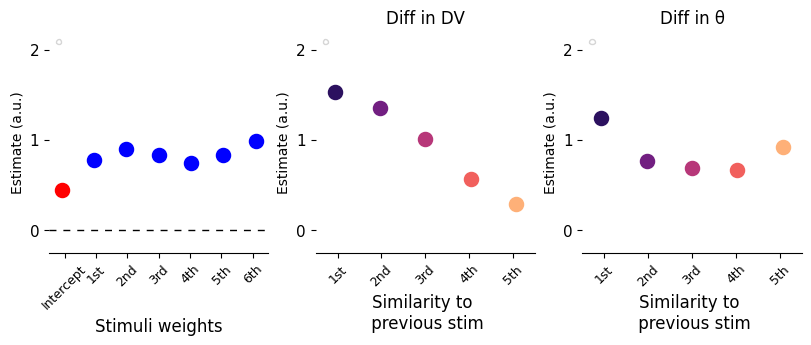

In [124]:

#estims = md_3reps_betas.copy()
fig, axes = plt.subplots(1, 3, figsize=(8,2.5))
fig.tight_layout(pad=0.0)


# First I plot the betas of each stim and intercept
i = 0
#axes[i].set_title(iparam, fontsize=15)
stim = md_stim_coefs
g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
dodge=True, join=False, ci=None,scale=1.5,  palette = ['red','blue','blue','blue','blue','blue','blue'], errwidth=0, capsize=0, ax=axes[i])
plt.setp(g.collections, alpha=.6) # set alpha for all points

axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

axes[i].spines['top'].set_visible(False)
axes[i].spines['right'].set_visible(False)
axes[i].spines['left'].set_visible(False)
# for legend text
axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
axes[i].set_xlabel('Parameter', fontsize = 0)
axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

axes[i].set_xlabel('Stimuli weights', fontsize = 12)
axes[i].margins(y=0.2)
axes[i].set_ylim([-.25, 2.2])
axes[i].set_yticks([0,1,2])
axes[i].set_xticklabels(['Intercept', '1st','2nd','3rd','4th','5th','6th'], rotation=45)
axes[i].tick_params(axis='y', labelsize=11) 
axes[i].tick_params(axis='x', labelsize=9) 

# Second, I plot the betas as a function of the physical and dv difference
sp_titles = ['Diff in DV','Diff in θ']

for i, iparam in enumerate(stim_models):
    i = i+1
    axes[i].set_title(sp_titles[i-1], fontsize=12)
    stim = iparam[iparam['parameter']  != '(Intercept)']
    g = sns.pointplot(data=stim, x="parameter", y="Estimate"  ,linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5,  palette = "magma", errwidth=0, capsize=0, ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    #axes[i].spines['bottom'].set_visible(False)

    # for legend text
    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})
    
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].set_xlabel('Similarity to \n previous stim', fontsize = 12)
    axes[i].margins(y=0.2)
    axes[i].set_ylim([-.25, 2.2])
    axes[i].set_yticks([0,1,2])
    axes[i].set_xticklabels(['1st','2nd','3rd','4th','5th'], rotation=45)
    axes[i].tick_params(axis='x', labelsize=9) 
    axes[i].tick_params(axis='y', labelsize=11) 


figpath = os.path.join(figures_path, 'CJ_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)

__Effect of previous choice__

/tmp/ipykernel_292482/897441355.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',
/tmp/ipykernel_292482/897441355.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',


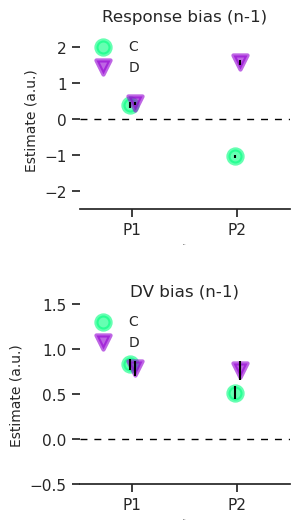

In [571]:
x_limits = np.array([[-2.5, 2.5] ,[-0.5, 1.5]])
estims = organize_data_betas(lmm_models['CJ_exp']['md_CJ_exp'].coefs, 1, False)


fig, axes = plt.subplots(2, 1, figsize=(4,6))
fig.tight_layout(pad=2)

sp_titles = ['Response bias (n-1)','DV bias (n-1)']

for i, iparam in enumerate(['bias','weight']):

    axes[i].set_title(sp_titles[i], fontsize=12)
    stim = estims[estims.parameter == iparam]
    g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    for point_pair in axes[i].collections:
        for x, y in point_pair.get_offsets():
            x_coords.append(x)
            y_coords.append(y)

    axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)

    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

    axes[i].margins(y=0.3)
    axes[i].set_ylim(x_limits[i])

    axes[i].set_xlabel('nrep', fontsize = 0)
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].set_xlim([-0.5,1.5])
    axes[i].margins(x=0.2)
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['P1', 'P2'])
    axes[i].tick_params(axis='y', labelsize=11) 
    axes[i].tick_params(axis='x', labelsize=11) 



figpath = os.path.join(figures_path, 'CJ_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


__Effect of previous choice__

Plot trial repeat effect. I will plot this effect separated from the repeat interaction

/tmp/ipykernel_292482/1816145764.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',
/tmp/ipykernel_292482/1816145764.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='',


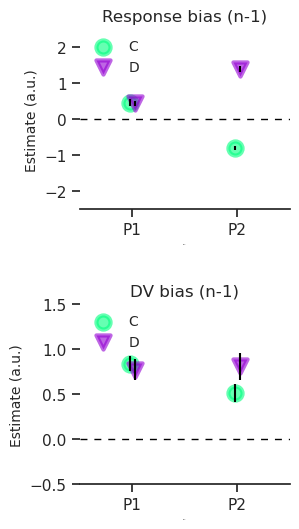

In [620]:
x_limits = np.array([[-2.5, 2.5] ,[-0.5, 1.5]])
estims = organize_data_param(lmm_models['CJ_exp']['md_CJ_rep_exp'].coefs, 1,'trial_typerepeat')

fig, axes = plt.subplots(2, 1, figsize=(4,6))
fig.tight_layout(pad=2)

sp_titles = ['Response bias (n-1)','DV bias (n-1)']

for i, iparam in enumerate(['bias','weight']):

    axes[i].set_title(sp_titles[i], fontsize=12)
    stim = estims[estims.parameter == iparam]
    g = sns.pointplot(data=stim, x="nrep" , y="Estimate" , hue="prev_resp",linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    for point_pair in axes[i].collections:
        for x, y in point_pair.get_offsets():
            x_coords.append(x)
            y_coords.append(y)

    axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)

    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10}, fontsize=12,  framealpha= 0.0)

    axes[i].margins(y=0.3)
    axes[i].set_ylim(x_limits[i])

    axes[i].set_xlabel('nrep', fontsize = 0)
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10}); 

    axes[i].set_xlim([-0.5,1.5])
    axes[i].margins(x=0.2)
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['P1', 'P2'])
    axes[i].tick_params(axis='y', labelsize=11) 
    axes[i].tick_params(axis='x', labelsize=11) 



figpath = os.path.join(figures_path, 'CJ_RC_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


/tmp/ipykernel_292482/625646125.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
/tmp/ipykernel_292482/625646125.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


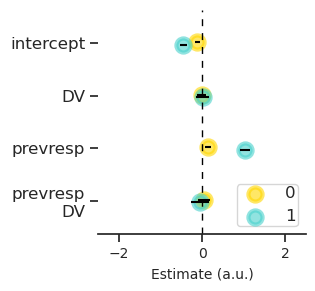

In [621]:

x_limits = np.array([[-2.5, 2.5], [-1.5, 1.5]])
estims = organize_data_param(lmm_models['CJ_exp']['md_CJ_rep_exp'].coefs, 1, 'trial_typerepeat')

# Create the single subplot
fig, axes = plt.subplots(1, 1, figsize=(3.5, 3.25))
fig.tight_layout(pad=1.0)

# Set subplot title
#axes.set_title('Effect of repetition', fontsize=15)

stim = estims[(estims.parameter != 'bias') & (estims.parameter != 'weight')]

g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
                  dodge=True, join=False, ci=None, scale=1.5, palette=colpal2, errwidth=0, capsize=0,
                  markers=['o', 'o', 'o'], ax=axes)
plt.setp(g.collections, alpha=.6)  # set alpha for all points

# Find the x,y coordinates for each point
x_coords = []
y_coords = []
for point_pair in axes.collections:
    for x, y in point_pair.get_offsets():
        x_coords.append(x)
        y_coords.append(y)

axes.axvline(x=0, color='black', linewidth=1, linestyle="dashed", dashes=(5, 5))

axes.errorbar(x_coords, y_coords, xerr=np.abs(stim[["2.5_ci", "97.5_ci"]].T - stim['Estimate']),
              fmt=' ', zorder=3, ecolor='black')

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.spines['left'].set_visible(False)

# for legend text
axes.legend(loc='lower right', borderpad=0.1, prop={'size': 12})

axes.set_ylabel('', fontsize=10)
axes.tick_params(axis='x', labelsize=10, rotation=0)

lab_names = ['intercept', 'DV', 'prevresp', 'prevresp\nDV']
axes.tick_params(axis='y', labelsize=12, rotation=0)
axes.set_yticklabels(lab_names, minor=False)
axes.margins(y=0.2)
axes.set_xlim([-2.5, 2.5])

axes.set_xlabel('Estimate (a.u.)', fontsize=10)
# Adjust the layout to prevent overlap
plt.tight_layout()



figpath = os.path.join(figures_path, 'CJ_RC_interac_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3535275637.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3535275637.py:13: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3535275637.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
/var/folders/4m/3h_3fwxd7v33qzl6mfvbj3tr0000gn/T/ipykernel_85357/3535275637.py:13: UserWarn

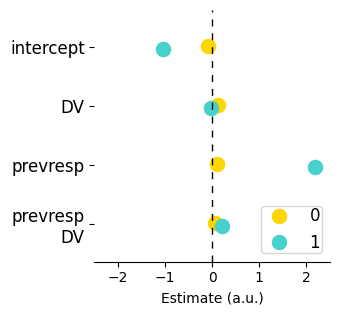

In [125]:

x_limits = np.array([[-2.5, 2.5], [-1.5, 1.5]])
estims = organize_data_param(lmm_models['CJ_exp']['md_CJ_full_confi_exp'].coefs, 1,'Confidence1')

# Create the single subplot
fig, axes = plt.subplots(1, 1, figsize=(3.5, 3.25))
fig.tight_layout(pad=1.0)

# Set subplot title
#axes.set_title('Effect of repetition', fontsize=15)

stim = estims[(estims.parameter != 'bias') & (estims.parameter != 'weight')]

g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
                  dodge=True, join=False, ci=None, scale=1.5, palette=colpal2, errwidth=0, capsize=0
                , ax=axes)
plt.setp(g.collections, alpha=.6)  # set alpha for all points


axes.axvline(x=0, color='black', linewidth=1, linestyle="dashed", dashes=(5, 5))



axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.spines['left'].set_visible(False)

# for legend text
axes.legend(loc='lower right', borderpad=0.1, prop={'size': 12})

axes.set_ylabel('', fontsize=10)
axes.tick_params(axis='x', labelsize=10, rotation=0)

lab_names = ['intercept', 'DV', 'prevresp', 'prevresp\nDV']
axes.tick_params(axis='y', labelsize=12, rotation=0)
axes.set_yticklabels(lab_names, minor=False)
axes.margins(y=0.2)
axes.set_xlim([-2.5, 2.5])

axes.set_xlabel('Estimate (a.u.)', fontsize=10)
# Adjust the layout to prevent overlap
plt.tight_layout()



figpath = os.path.join(figures_path, 'CJ_RC_interac_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


/tmp/ipykernel_292482/311801470.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
/tmp/ipykernel_292482/311801470.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


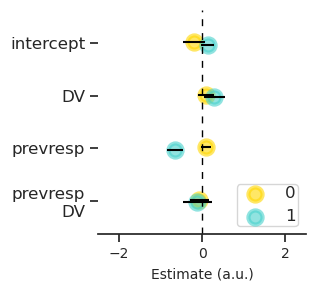

In [625]:

x_limits = np.array([[-2.5, 2.5], [-1.5, 1.5]])
estims = organize_data_param(lmm_models['CJ_exp']['md_CJnrep_metad_exp'].coefs, 1,'metad')


# Create the single subplot
fig, axes = plt.subplots(1, 1, figsize=(3.5, 3.25))
fig.tight_layout(pad=1.0)

# Set subplot title
#axes.set_title('Effect of repetition', fontsize=15)

stim = estims[(estims.parameter != 'bias') & (estims.parameter != 'weight')]

g = sns.pointplot(data=stim, x="Estimate", y="parameter", hue="nrep", linestyles='',
                  dodge=True, join=False, ci=None, scale=1.5, palette=colpal2, errwidth=0, capsize=0,
                  markers=['o', 'o', 'o'], ax=axes)
plt.setp(g.collections, alpha=.6)  # set alpha for all points

# Find the x,y coordinates for each point
x_coords = []
y_coords = []
for point_pair in axes.collections:
    for x, y in point_pair.get_offsets():
        x_coords.append(x)
        y_coords.append(y)

axes.axvline(x=0, color='black', linewidth=1, linestyle="dashed", dashes=(5, 5))

axes.errorbar(x_coords, y_coords, xerr=np.abs(stim[["2.5_ci", "97.5_ci"]].T - stim['Estimate']),
              fmt=' ', zorder=3, ecolor='black')

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.spines['left'].set_visible(False)

# for legend text
axes.legend(loc='lower right', borderpad=0.1, prop={'size': 12})

axes.set_ylabel('', fontsize=10)
axes.tick_params(axis='x', labelsize=10, rotation=0)

lab_names = ['intercept', 'DV', 'prevresp', 'prevresp\nDV']
axes.tick_params(axis='y', labelsize=12, rotation=0)
axes.set_yticklabels(lab_names, minor=False)
axes.margins(y=0.2)
axes.set_xlim([-2.5, 2.5])

axes.set_xlabel('Estimate (a.u.)', fontsize=10)
# Adjust the layout to prevent overlap
plt.tight_layout()



figpath = os.path.join(figures_path, 'CJ_RC_interac_coeff.pdf')
plt.savefig(figpath ,bbox_inches='tight', dpi = 300)


The effect of confidence in participants responses

/tmp/ipykernel_292482/2271557871.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep", y="Estimate"  , hue="prev_resp",linestyles='',
/tmp/ipykernel_292482/2271557871.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep", y="Estimate"  , hue="prev_resp",linestyles='',
/tmp/ipykernel_292482/2271557871.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate", hue="nrep", linestyles='',


(-0.5, 4.0)

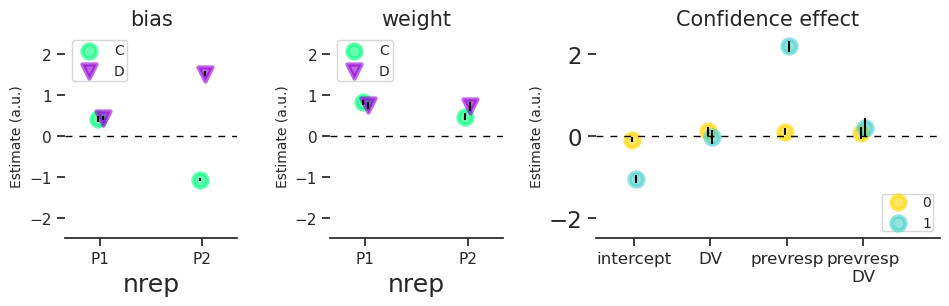

In [246]:
x_limits = np.array([[-2.5, 2.5] ,[-2.5, 2.5]])
estims = organize_data_param(lmm_models['CJ_exp']['md_CJ_full_confi_exp'].coefs, 1,'Confidence1')
fig, axes = plt.subplots(1, 3, figsize=(10,3), gridspec_kw={'width_ratios': [1, 1, 2]})
fig.tight_layout(pad=1.0)

for i, iparam in enumerate(['bias','weight']):
    axes[i].set_title(iparam, fontsize=15)
    stim = estims[estims.parameter == iparam]
    g = sns.pointplot(data=stim, x="nrep", y="Estimate"  , hue="prev_resp",linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    for point_pair in axes[i].collections:
        for x, y in point_pair.get_offsets():
            x_coords.append(x)
            y_coords.append(y)

    axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    #x.spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    # for legend text
    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})

    axes[i].margins(x=0.3)
    axes[i].set_ylim(x_limits[i])

    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['P1', 'P2'])
    axes[i].tick_params(axis='y', labelsize=11) 
    axes[i].tick_params(axis='x', labelsize=11) 
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10})

i = 2
axes[i].set_title('Confidence effect', fontsize=15)
stim = estims[(estims.parameter != 'bias') & (estims.parameter != 'weight')]

g = sns.pointplot(data=stim, x="parameter", y="Estimate", hue="nrep", linestyles='', 
dodge=True, join=False, ci=None,scale=1.5, palette = colpal2,errwidth=0, capsize=0,markers=['o', 'o', 'o'], ax=axes[i])
plt.setp(g.collections, alpha=.6) # set alpha for all points
# Find the x,y coordinates for each point
x_coords = []
y_coords = []
for point_pair in axes[i].collections:
    for x, y in point_pair.get_offsets():
        x_coords.append(x)
        y_coords.append(y)

axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
fmt=' ', zorder=3, ecolor = 'black')

axes[i].spines['top'].set_visible(False)
axes[i].spines['right'].set_visible(False)
#x.spines['bottom'].set_visible(False)
axes[i].spines['left'].set_visible(False)
# for legend text
axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10})
axes[i].legend(loc='lower right', borderpad=0.1,prop={'size':10})
axes[i].set_xlabel('', fontsize=10)
axes[i].tick_params(axis='x', labelsize=12,rotation = 0)
lab_names = ['intercept', 'DV','prevresp','prevresp\nDV']
axes[i].set_xticklabels(lab_names, minor=False)
axes[i].margins(x=0.2)
axes[i].set_ylim([-2.5, 2.5])
axes[i].set_xlim([-0.5, 4])

/tmp/ipykernel_292482/1270026117.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep", y="Estimate"  , hue="prev_resp",linestyles='',
/tmp/ipykernel_292482/1270026117.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="nrep", y="Estimate"  , hue="prev_resp",linestyles='',
/tmp/ipykernel_292482/1270026117.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.pointplot(data=stim, x="parameter", y="Estimate", hue="nrep", linestyles='',


Text(502.7132352941177, 0.5, 'Estimate (a.u.)')

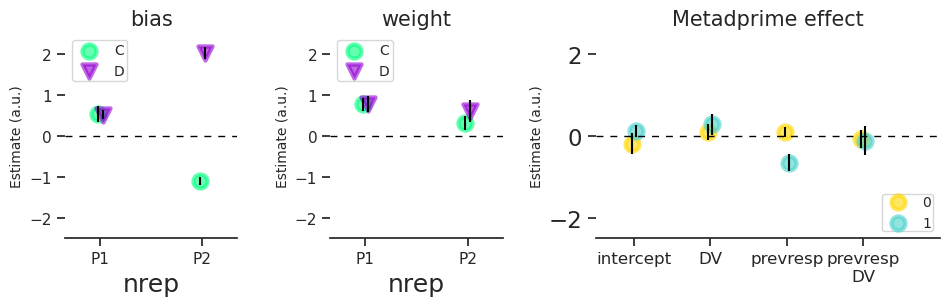

In [250]:
x_limits = np.array([[-2.5, 2.5] ,[-2.5, 2.5]])
estims = organize_data_param(lmm_models['CJ_exp']['md_CJnrep_metad_exp'].coefs, 1,'metad')
fig, axes = plt.subplots(1, 3, figsize=(10,3), gridspec_kw={'width_ratios': [1, 1, 2]})
fig.tight_layout(pad=1.0)

for i, iparam in enumerate(['bias','weight']):
    axes[i].set_title(iparam, fontsize=15)
    stim = estims[estims.parameter == iparam]
    g = sns.pointplot(data=stim, x="nrep", y="Estimate"  , hue="prev_resp",linestyles='', 
    dodge=True, join=False, ci=None,scale=1.5, palette = colpal3,errwidth=0, capsize=0,markers=['o', 'v', 's'], ax=axes[i])
    plt.setp(g.collections, alpha=.6) # set alpha for all points
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []
    for point_pair in axes[i].collections:
        for x, y in point_pair.get_offsets():
            x_coords.append(x)
            y_coords.append(y)

    axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

    axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
    fmt=' ', zorder=3, ecolor = 'black')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    #x.spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    # for legend text
    axes[i].legend(loc='upper left', borderpad=0.2,prop={'size':10})

    axes[i].margins(x=0.3)
    axes[i].set_ylim(x_limits[i])

    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['P1', 'P2'])
    axes[i].tick_params(axis='y', labelsize=11) 
    axes[i].tick_params(axis='x', labelsize=11) 
    axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10})

i = 2
axes[i].set_title('Metadprime effect', fontsize=15)
stim = estims[(estims.parameter != 'bias') & (estims.parameter != 'weight')]

g = sns.pointplot(data=stim, x="parameter", y="Estimate", hue="nrep", linestyles='', 
dodge=True, join=False, ci=None,scale=1.5, palette = colpal2,errwidth=0, capsize=0,markers=['o', 'o', 'o'], ax=axes[i])
plt.setp(g.collections, alpha=.6) # set alpha for all points
# Find the x,y coordinates for each point
x_coords = []
y_coords = []
for point_pair in axes[i].collections:
    for x, y in point_pair.get_offsets():
        x_coords.append(x)
        y_coords.append(y)

axes[i].axhline(y = 0, color = 'black', linewidth = 1, linestyle="dashed",dashes=(5, 5))

axes[i].errorbar(x_coords, y_coords, yerr=np.abs(stim[["2.5_ci","97.5_ci"]].T - stim['Estimate']),
fmt=' ', zorder=3, ecolor = 'black')

axes[i].spines['top'].set_visible(False)
axes[i].spines['right'].set_visible(False)
#x.spines['bottom'].set_visible(False)
axes[i].spines['left'].set_visible(False)
# for legend text
axes[i].legend(loc='lower right', borderpad=0.1,prop={'size':10})
axes[i].set_xlabel('', fontsize=10)
axes[i].tick_params(axis='x', labelsize=12,rotation = 0)
lab_names = ['intercept', 'DV','prevresp','prevresp\nDV']
axes[i].set_xticklabels(lab_names, minor=False)
axes[i].margins(x=0.2)
axes[i].set_ylim([-2.5, 2.5])
axes[i].set_xlim([-0.5, 4])
axes[i].set_ylabel('Estimate (a.u.)', fontdict={'size':10})

## __CJ metadprime effect__

__Two stage regression models__

In [120]:
def log_reg_prevfit(x, f): # this function was used to calculate the log linear regression between two vectors
    x.nrep = np.array(x.nrep)
    reg = smf.glm(formula = f, data = x, family=sm.families.Binomial()).fit()
    params = reg.params
    #PSE = - reg.params.Intercept/reg.params[1]
    # concatenating parameters
    if np.max(x.nrep) == 2:
        out = pd.DataFrame({'intercept0':[params[0]] , 'intercept1':[params[1]], 'intercept2':[params[2]], 'prev0':[params[3]], 'prev1':[params[3] + params[4]], 'prev2':[params[3] + params[5]], 
                            'weight0':[params[6]],'weight1':[params[6] + params[7]],'weight2':[params[6]+ params[8]],'prevweight0':[params[9]],'prevweight1':[params[10]+params[9]],'prevweight2':[params[11]+params[9]]})
    if np.max(x.nrep) == 1:
        out = pd.DataFrame({'intercept0':[params[0]] , 'intercept1':[params[1]],  'prev0':[params[2]], 'prev1':[params[3] + params[2]], 
                            'weight0':[params[4]],'weight1':[params[4] + params[5]],'prevweight0':[params[6]],'prevweight1':[params[6]+params[7]]})
   
    return out #intercept + weight
 

In [121]:
formula = "Responses ~ C(nrep)*C(response1)*dv"
log_regpre_deci_params = dflong.groupby([ 'id_subj','exp_ID']).apply(log_reg_prevfit, formula)
log_regpre_deci_params.reset_index(inplace = True)
log_regpre_deci_params.head()

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/309051864.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  out = pd.DataFrame({'intercept0':[params[0]] , 'intercept1':[params[1]], 'intercept2':[params[2]], 'prev0':[params[3]], 'prev1':[params[3] + params[4]], 'prev2':[params[3] + params[5]],
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/309051864.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'weight0':[params[6]],'weight1':[params[6] + params[7]],'weight2':[params[6]+ params[8]],'prevweight0':[params[9]],'prevweight1':[params[10]+params[9]],'prevweight2':[params[11]+params

,id_subj,exp_ID,level_2,intercept0,intercept1,intercept2,prev0,prev1,prev2,weight0,weight1,weight2,prevweight0,prevweight1,prevweight2
0,1,3diffs,0,0.273215,-2.591835,-2.997438,-0.014151,4.172037,5.379882,0.872215,0.628230,1.156060,0.004125,0.341573,-0.438025
1,2,3diffs,0,0.423471,-1.722381,-2.410635,0.025533,2.986598,4.175755,0.886938,1.000581,0.690471,-0.036223,0.060712,0.253817
2,3,3diffs,0,0.549506,-0.997848,-1.342415,0.363829,2.089022,2.552093,1.158344,0.647069,0.597360,-0.376940,-0.179236,0.003187
3,4,3diffs,0,0.714806,-1.890327,-2.199547,-0.234305,2.885671,4.375902,0.816864,0.543354,0.750926,-0.077408,0.212446,0.223939
4,5,3diffs,0,0.379008,-1.884463,-1.795698,0.208734,3.077888,3.300579,0.736652,0.529010,0.442309,0.090019,-0.065285,0.142447


In [122]:

df_betas = pd.melt(log_regpre_deci_params, id_vars=['id_subj','exp_ID'], value_vars=['intercept0', 'intercept1',
       'intercept2', 'prev0', 'prev1', 'prev2', 'weight0', 'weight1', 'weight2', 'prevweight0', 'prevweight1', 'prevweight2'])
df_betas.rename(columns={'variable' : "parameter"}, inplace=True)
#df_betas.head(4)
df_betas = df_betas.groupby(['id_subj','exp_ID','parameter'])['value'].mean()


df_betas = df_betas.reset_index()
df_betas  = df_betas.loc[~df_betas.value.isnull()]
df_betas['nrep'] = 0
df_betas.loc[df_betas['parameter'].str.contains('1'),'nrep'] = 1
df_betas.loc[df_betas['parameter'].str.contains('2'),'nrep'] = 2
df_betas['parameter'] = df_betas['parameter'].str.replace('0', '')
df_betas['parameter'] = df_betas['parameter'].str.replace('1', '')
df_betas['parameter'] = df_betas['parameter'].str.replace('2', '')
df_betas.head(5)

,id_subj,exp_ID,parameter,value,nrep
0,1,3diffs,intercept,0.273215,0
1,1,3diffs,intercept,-2.591835,1
2,1,3diffs,intercept,-2.997438,2
3,1,3diffs,prev,-0.014151,0
4,1,3diffs,prev,4.172037,1


In [123]:
df_betas_sct = df_betas[df_betas.parameter == 'intercept']
df_betas_sct.reset_index(inplace = True)
df_betas_sct.rename(columns={'value' : "intercept"}, inplace=True)
aux = df_betas[df_betas.parameter == 'prev'].reset_index()
df_betas_sct['prev'] = aux['value']
aux = df_betas[df_betas.parameter == 'weight'].reset_index()
df_betas_sct['weight'] = aux['value']
aux = df_betas[df_betas.parameter == 'prevweight'].reset_index()
df_betas_sct['prevweight'] = aux['value']

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/2843734272.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_betas_sct.rename(columns={'value' : "intercept"}, inplace=True)
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/2843734272.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_betas_sct['prev'] = aux['value']
/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/2843734272.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)


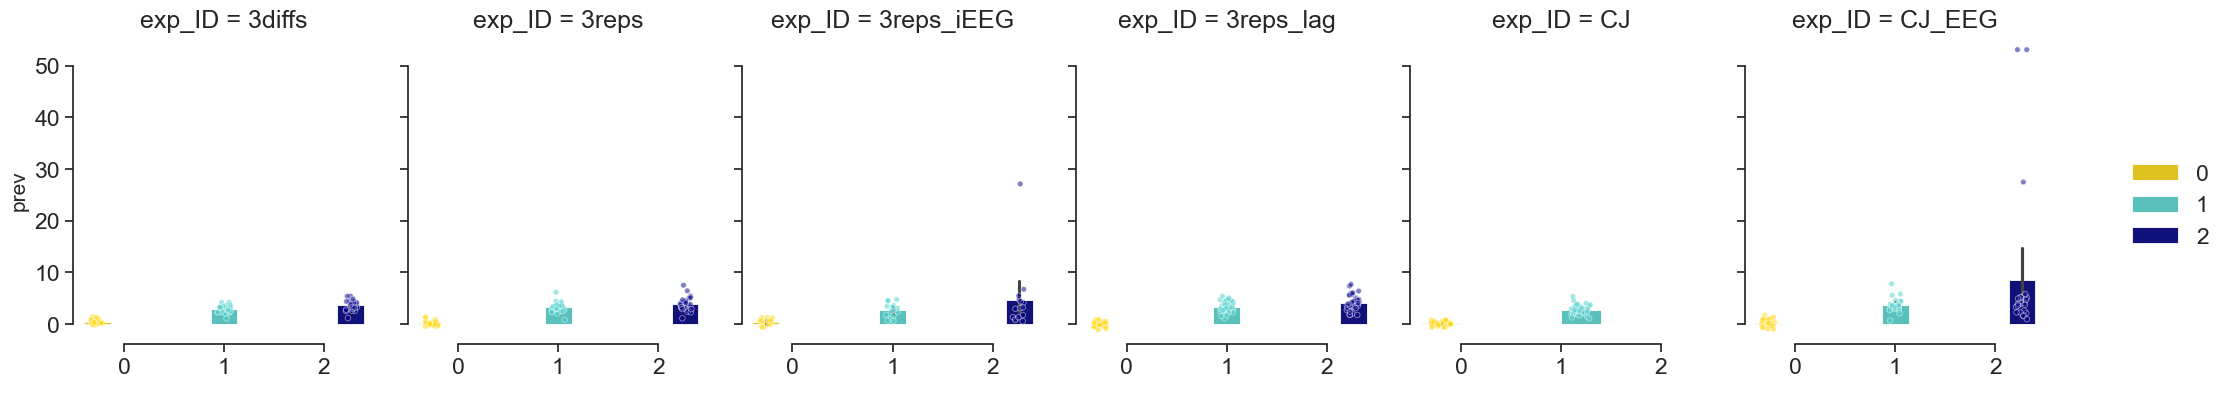

In [124]:
sizeplot = {}; sizeplot['height'] = 4.5; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'prev'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'nrep'; dy = 'value'; hue = 'nrep';  row = None; col = 'exp_ID'
pal = colpal2
#maskout = (df_betas.exp_ID == '3reps') & (df_betas.parameter != 'intercept') & (df_betas.parameter != 'deci_prev')  & (df_betas.parameter != 'G1ori')  & (df_betas.parameter != 'G2ori') & (df_betas.parameter != 'G3ori')  & (df_betas.parameter != 'G4ori')  & (df_betas.parameter != 'G5ori')  & (df_betas.parameter != 'G6ori') 

barsplot(df_betas[df_betas.parameter == 'prev'], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = True)

#myviolinplot(df_betas[(df_betas.parameter != 'intercept') ], dx, dy, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 5)

/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/mne_pymer4/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)


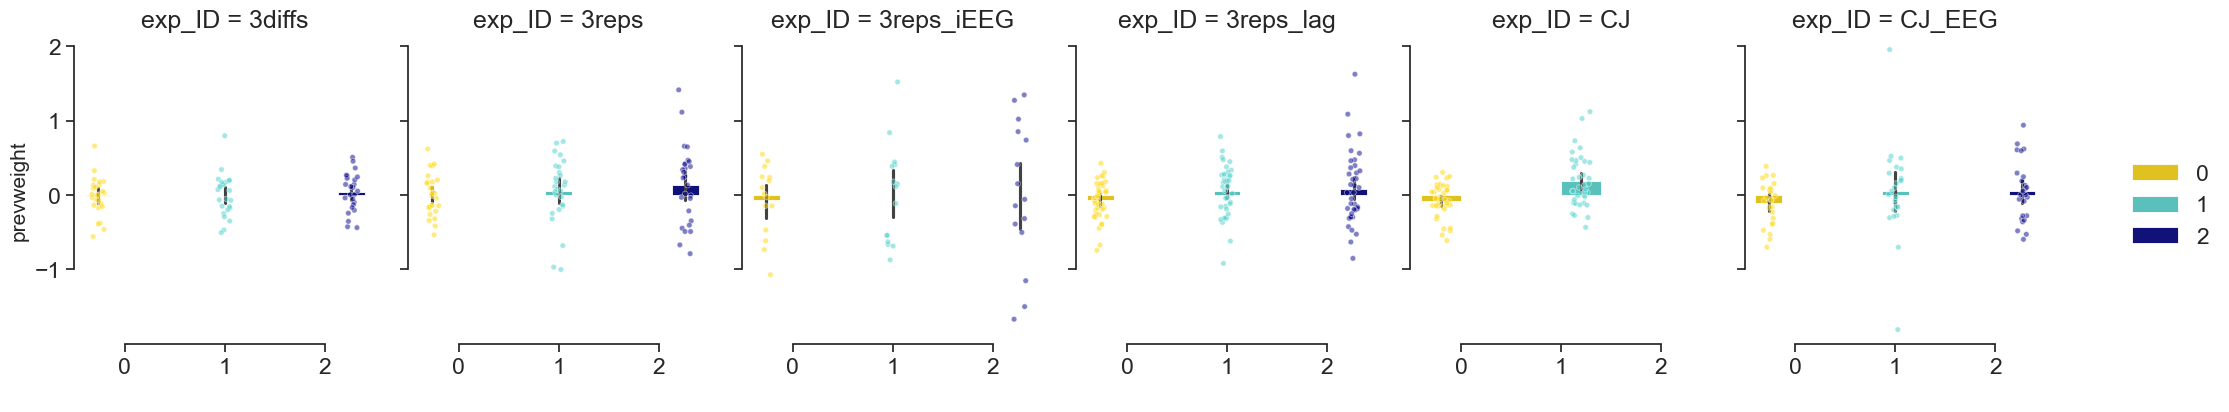

In [125]:
sizeplot = {}; sizeplot['height'] = 4.5; sizeplot['aspect'] = 0.8
axislabels = {}; axislabels['xlabel'] = ' '; axislabels['ylabel']= 'prevweight'
yaxis = None # yaxis = {}; yaxis['ylim']=[-2,4], yaxis['yticks']=[-2, 0, 2, 4]
dx = 'nrep'; dy = 'value'; hue = 'nrep';  row = None; col = 'exp_ID'
pal = colpal2
#maskout = (df_betas.exp_ID == '3reps') & (df_betas.parameter != 'intercept') & (df_betas.parameter != 'deci_prev')  & (df_betas.parameter != 'G1ori')  & (df_betas.parameter != 'G2ori') & (df_betas.parameter != 'G3ori')  & (df_betas.parameter != 'G4ori')  & (df_betas.parameter != 'G5ori')  & (df_betas.parameter != 'G6ori') 

barsplot(df_betas[df_betas.parameter == 'prevweight'], dx, dy, hue, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 4, dodge = True)

#myviolinplot(df_betas[(df_betas.parameter != 'intercept') ], dx, dy, col, row, pal, sizeplot, yaxis, axislabels, sizepoint = 5)

Getting metacognitive indexes

In [127]:
indiv_sdt = df.groupby([ 'id_subj','exp_ID']).apply(sdt)
indiv_sdt.reset_index(inplace=True)
merged_sdt = pd.merge( df[df.nrep == 0][['metad', 'id_subj']], indiv_sdt,on = ['id_subj'], how = 'inner') 
merged_sdt.drop_duplicates(subset = ['id_subj'], inplace = True)
merged_sdt['metad_eff'] = merged_sdt['metad'] / merged_sdt['dprime']

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/3067209949.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  indiv_sdt = df.groupby([ 'id_subj','exp_ID']).apply(sdt)


Calculating difference in enhancement between 2 and 1 repetition

In [128]:
CJ_df = df[df.exp_ID == 'CJ'].groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)
CJ_df.reset_index(inplace=True)
CJ_df_diff = CJ_df[CJ_df.nrep == 1].reset_index(drop=True)
aux = CJ_df[CJ_df.nrep == 0].reset_index(drop=True)
CJ_df_diff['diffdprime'] = CJ_df_diff['dprime'] - aux['dprime']

/var/folders/rx/vfyhhpqd7q172_xk2p75xp7w0000gn/T/ipykernel_37155/1710172459.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CJ_df = df[df.exp_ID == 'CJ'].groupby(['exp_ID', 'id_subj','nrep']).apply(sdt)


Merging all the CJ dataframes

In [129]:
metacog_df = pd.merge( merged_sdt[merged_sdt['exp_ID'] == 'CJ'], CJ_df_diff[['diffdprime', 'id_subj', 'exp_ID']],on = ['id_subj','exp_ID'], how = 'inner') 
metacog_df = pd.merge( metacog_df, df_betas[(df_betas.exp_ID == 'CJ') & (df_betas.nrep == 1)],on = ['id_subj'], how = 'inner') 
metacog_df.reset_index(inplace=True, drop=True)

In [130]:

# Compute the correlation and assess significance using bootstrap
corr, p_value, ci, sig = perm_test_corr(metacog_df['metad'], metacog_df['diffdprime'])

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"95% CI: ({ci[0]:.3f}, {ci[1]:.3f})")
print(f"Significant: {sig}")

Correlation: 0.241
P-value: 0.000
95% CI: (-0.162, 0.155)
Significant: True
